# Análisis de Clustering en Cáncer de Páncreas

## Identificación de genes y su relacion con datos clinicos por medio de agrupamiento

---

## Planteamiento del Problema y Contexto de los Datos

### El Cáncer de Páncreas: Un Problema de Alta Relevancia Clínica

El **adenocarcinoma ductal pancreático (PDAC)**, clasificado en TCGA como **PAAD** (*Pancreatic Adenocarcinoma*), representa una de las neoplasias malignas con peor pronóstico a nivel mundial. A pesar de los avances en oncología molecular, la tasa de supervivencia a 5 años sigue siendo de apenas el **12%**, principalmente debido a su diagnóstico tardío y a la falta de marcadores moleculares fiables para estratificar a los pacientes.

Desde una perspectiva molecular, el cáncer de páncreas es extraordinariamente heterogéneo: distintos pacientes con el mismo diagnóstico clínico pueden presentar perfiles de expresión génica completamente diferentes, lo que se traduce en respuestas distintas a los tratamientos disponibles. Identificar **subgrupos moleculares** dentro de esta enfermedad es, por lo tanto, un paso fundamental para avanzar hacia una medicina de precisión.

### Objetivo del Análisis

El objetivo central de este proyecto es aplicar técnicas de **aprendizaje no supervisado** para descubrir estructura latente en los datos de expresión génica del cáncer de páncreas. Específicamente, se busca:

1. **Reducir la dimensionalidad** de los datos mediante PCA para explorar la estructura global del dataset.
2. **Identificar subgrupos de pacientes** con perfiles moleculares similares mediante algoritmos de clustering (K-means y Hierarchical Clustering).
3. **Caracterizar clínicamente** cada subgrupo encontrado, relacionándolo con variables como estadio de la enfermedad, supervivencia, género y edad.
4. **Identificar genes diferencialmente expresados** entre los clusters, que potencialmente puedan servir como biomarcadores o dianas terapéuticas.

La pregunta central que guía este análisis es: **¿Existen subtipos moleculares bien definidos en el cáncer de páncreas que se asocien con diferencias clínicas o de supervivencia significativas?**

---

### 1.3 Fuente de los Datos

Los datos utilizados en este proyecto provienen de **The Cancer Genome Atlas (TCGA)**, accedidos a través de la plataforma **UCSC Xena** ([xenabrowser.net](https://xenabrowser.net)), específicamente de la cohorte:

> 📂 **GDC TCGA Pancreatic Cancer (PAAD)**  
> Fuente: [https://xenabrowser.net/datapages/?cohort=GDC%20TCGA%20Pancreatic%20Cancer%20(PAAD)](https://xenabrowser.net/datapages/?cohort=GDC%20TCGA%20Pancreatic%20Cancer%20(PAAD))

TCGA es un consorcio que ha caracterizado genómicamente más de 20,000 tumores primarios de 33 tipos de cáncer distintos. Los datos de la plataforma GDC (*Genomic Data Commons*) han sido re-analizados de forma uniforme utilizando el ensamblaje de referencia del genoma humano **hg38**, garantizando consistencia y reproducibilidad.

Se trabajó con **tres archivos principales**:

| Dataset | Descripción |
|---|---|
| `STAR - TPM` | Datos de expresión génica (RNA-seq), cuantificados en TPM (*Transcripts Per Million*) mediante el alineador STAR |
| `GDC Phenotype` | Variables clínicas del paciente: estadio, género, edad al diagnóstico, histología, entre otras |
| `Survival data` | Datos de supervivencia: tiempo de seguimiento y estado vital (vivo/muerto) para análisis de pronóstico |

> **Nota sobre los datos de expresión génica:** Los valores de TPM representan la abundancia relativa de transcritos, normalizando tanto por la longitud del gen como por la profundidad de secuenciación, lo que facilita la comparación entre muestras.

---

### Justificación del Enfoque

El análisis de expresión génica a escala genómica genera datos de **alta dimensionalidad** (decenas de miles de genes por muestra), lo que plantea desafíos computacionales y estadísticos considerables. Las técnicas de aprendizaje no supervisado permiten abordar este problema sin depender de etiquetas previas, revelando estructura que puede ser clínicamente relevante y que de otro modo permanecería oculta.

Estudios previos utilizando los mismos datos de TCGA-PAAD han identificado entre 2 y 4 subtipos moleculares con diferencias significativas en supervivencia y respuesta a quimioterapia, lo que valida la pertinencia del enfoque utilizado en este proyecto.

### Metodología

- Exploración del conjunto de datos
- Tratamiento de datos
- Reducción de dimensionalidad
- Construcción y comparación de modelos de clustering
- Interpretacion de cluster / analisis de genes
- Interpretación de cluster / analisis clinico
- Comparación con un articulo cientifico
- Conclusión

---

### Exploración y contexto de los datos

Cabe recalcar que no somos genetistas y mucho menos medicos, de modo que no podemos explicar cada uno de los miles genes que podemos llegar, tendriamos un glosario demasiado grande, por lo que lo trabajaremos no sin saber el contexto de los genes, pero con logica y un buen enfoque para tratar datos.

Haremos el mejor esfuerzo posible.

### Importar Datos

Vamos a importar los distintos datasets que tendremos que utilizar, como mencionamos son 3.

In [48]:
import pandas as pd
import gzip

# Correctly read each .tsv.gz file using pandas
clinical = pd.read_csv('/content/drive/MyDrive/Inteligencia_Artificial_1/Proyecto 3/TCGA-PAAD.clinical.tsv.gz', sep='\t', on_bad_lines='skip')
tpm = pd.read_csv('/content/drive/MyDrive/Inteligencia_Artificial_1/Proyecto 3/TCGA-PAAD.star_tpm.tsv.gz', sep='\t', on_bad_lines='skip')
survival = pd.read_csv('/content/drive/MyDrive/Inteligencia_Artificial_1/Proyecto 3/TCGA-PAAD.survival.tsv.gz', sep='\t', on_bad_lines='skip')


Datos clinicos

In [49]:
clinical.shape

(196, 89)

Tenemos 196 muestras (observaciones de pacientes) y 89 variables clinicas para trabajar

In [50]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 89 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     196 non-null    object 
 1   id                                                         196 non-null    object 
 2   disease_type                                               196 non-null    object 
 3   case_id                                                    196 non-null    object 
 4   submitter_id                                               196 non-null    object 
 5   primary_site                                               196 non-null    object 
 6   cigarettes_per_day.exposures                               59 non-null     float64
 7   alcohol_history.exposures                                  196 non-null    object 
 8   years_smok

Datos TPM (Datos geneticos)

In [51]:
tpm.shape

(60660, 184)

In [52]:
tpm

,Ensembl_ID,TCGA-IB-A6UG-01A,TCGA-3A-A9IU-01A,TCGA-FB-A545-01A,TCGA-IB-AAUQ-01A,TCGA-HV-A5A3-01A,TCGA-IB-7897-01A,TCGA-HV-AA8V-01A,TCGA-HV-A5A5-01A,TCGA-HZ-8638-01A,...,TCGA-2J-AAB9-01A,TCGA-IB-AAUT-01A,TCGA-OE-A75W-01A,TCGA-2J-AAB4-01A,TCGA-IB-7652-01A,TCGA-3A-A9I9-01A,TCGA-XN-A8T3-01A,TCGA-IB-7649-01A,TCGA-2J-AAB8-01A,TCGA-3A-A9IB-01A
0,ENSG00000000003.15,5.148837,5.725542,4.667376,4.433741,5.113963,4.739611,4.817828,5.008263,5.238485,...,5.008845,5.034176,4.347283,4.917403,4.651167,4.407890,5.628916,5.251924,4.603798,5.274042
1,ENSG00000000005.6,0.000000,0.061707,0.000000,0.301588,0.000000,2.713278,0.061569,0.000000,0.155620,...,0.000000,0.078200,0.170053,0.000000,0.084064,0.484396,0.222063,0.154454,0.609093,0.112500
2,ENSG00000000419.13,5.806968,6.451112,6.630772,6.133746,6.749612,6.550859,5.936221,6.096724,6.352453,...,6.337492,5.947491,6.108366,6.133742,6.461267,5.943441,6.270172,5.807461,6.580254,6.243117
3,ENSG00000000457.14,2.621876,3.259453,2.963567,2.691154,3.652842,3.431035,2.824768,3.343493,4.098672,...,2.812046,2.910119,2.011567,2.954103,3.036820,2.221320,3.208486,2.784316,3.776809,2.474488
4,ENSG00000000460.17,1.457909,2.134057,2.222588,1.789479,2.337797,2.327285,1.326940,1.561399,2.190172,...,1.515763,1.542407,1.264536,1.683696,1.834671,1.144373,2.142446,1.218595,2.437174,1.781066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60655,ENSG00000288669.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60656,ENSG00000288670.1,2.667393,3.625376,3.225892,2.970007,3.552229,3.780583,2.923492,3.106281,3.225445,...,3.159016,2.700684,3.015551,3.236615,3.506881,2.910253,3.012336,2.863403,4.076910,3.090955
60657,ENSG00000288671.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60658,ENSG00000288674.1,0.043064,0.084473,0.073546,0.050606,0.000000,0.020484,0.047399,0.000000,0.055612,...,0.020911,0.060324,0.009204,0.047957,0.052138,0.015926,0.036327,0.000000,0.068189,0.017779


Este parece ser el dataset mas extenso, ya que cuenta con 60,660 observaciones y 184 columnas, lo cual puede indicarnos que tengamos que reducir sus dimensiones por algun metodo

Survival

In [53]:
survival.shape

(195, 4)

195 observaciones, 4 variables, bastante simple para empezar

In [54]:
survival

,sample,OS.time,OS,_PATIENT
0,TCGA-HZ-7922-01A,4.0,0,TCGA-HZ-7922
1,TCGA-HZ-A8P1-01A,7.0,0,TCGA-HZ-A8P1
2,TCGA-IB-AAUM-01A,8.0,0,TCGA-IB-AAUM
3,TCGA-RL-AAAS-01A,9.0,0,TCGA-RL-AAAS
4,TCGA-US-A77G-01A,12.0,1,TCGA-US-A77G
...,...,...,...,...
190,TCGA-HV-A5A6-01A,2036.0,1,TCGA-HV-A5A6
191,TCGA-3A-A9IN-01A,2084.0,0,TCGA-3A-A9IN
192,TCGA-3E-AAAZ-01A,2182.0,1,TCGA-3E-AAAZ
193,TCGA-3E-AAAY-01A,2285.0,0,TCGA-3E-AAAY


### Preparación y tratamiento de los datos

Con el fin de tener una mejor comprensión de los datos y poder trabajarlos mejor, vamos a buscar valores faltantes, valores atipicos y veamos sus respectivas distribuciones

In [55]:
#revisar datos clinicos para transformar
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 89 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     196 non-null    object 
 1   id                                                         196 non-null    object 
 2   disease_type                                               196 non-null    object 
 3   case_id                                                    196 non-null    object 
 4   submitter_id                                               196 non-null    object 
 5   primary_site                                               196 non-null    object 
 6   cigarettes_per_day.exposures                               59 non-null     float64
 7   alcohol_history.exposures                                  196 non-null    object 
 8   years_smok

Ahora, tenemos muchas columnas,89 para ser exactos, para reducirlas un poco, busquemos que tantos valores faltantes hay en cada una, seguramente habra algunas que podamos quitar.

### Buscar Valores faltantes

/tmp/ipykernel_11224/3554862290.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y='Missing Percentage', data=missing_df, palette=colors)


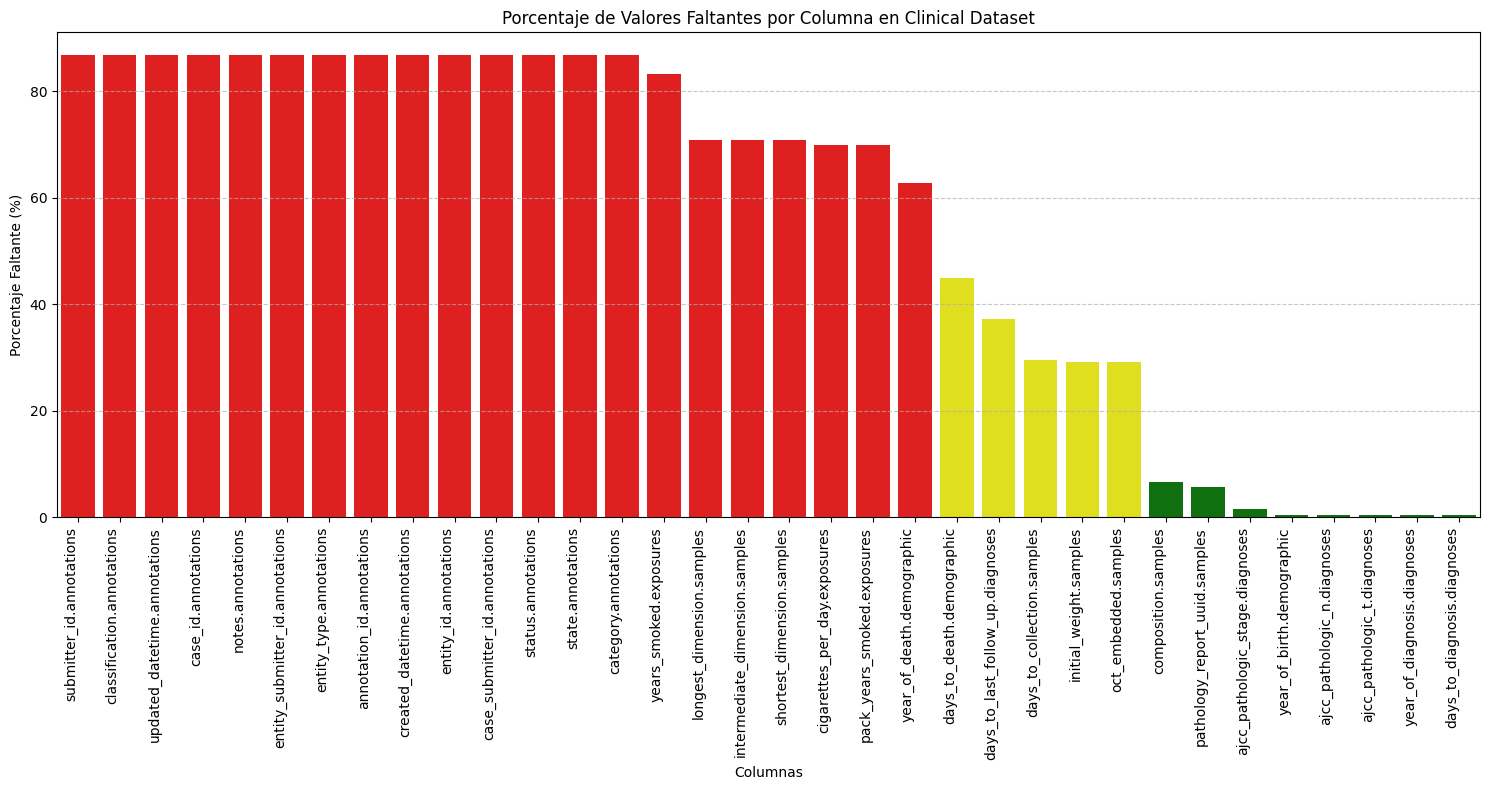

Columnas con valores faltantes y su porcentaje:


,Missing Percentage
submitter_id.annotations,86.734694
classification.annotations,86.734694
updated_datetime.annotations,86.734694
case_id.annotations,86.734694
notes.annotations,86.734694
entity_submitter_id.annotations,86.734694
entity_type.annotations,86.734694
annotation_id.annotations,86.734694
created_datetime.annotations,86.734694
entity_id.annotations,86.734694


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of missing values for each column
missing_percentages = clinical.isnull().sum() / len(clinical) * 100

# Filter out columns with no missing values and sort in descending order
missing_data = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

# Create a DataFrame for plotting
missing_df = missing_data.to_frame(name='Missing Percentage')

# Define colors based on thresholds
def get_bar_color(percentage):
    if percentage < 20:
        return 'green'
    elif percentage < 50:
        return 'yellow'
    else:
        return 'red'

colors = [get_bar_color(p) for p in missing_df['Missing Percentage']]

# Plotting the missing percentages
plt.figure(figsize=(15, 8))
sns.barplot(x=missing_df.index, y='Missing Percentage', data=missing_df, palette=colors)
plt.title('Porcentaje de Valores Faltantes por Columna en Clinical Dataset')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje Faltante (%)')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Columnas con valores faltantes y su porcentaje:")
display(missing_df)

Vaya, vemos que el dataset clinico se va a reducir drasticamente, usaremos un criterio para establecer que una variable sera eliminada del dataset si los datos faltantes superan el 45% (de la variable de `days_to_death.demographic`), esto ya que arriba de ese porcentaje los datos no son manejables ya que si quisieramos rellenarlos, basicamente estamos inventando datos, lo cual no es el enfoque de este analisis

In [57]:
columns_to_drop = missing_percentages[missing_percentages > 45].index
print(f"Columns to be dropped due to more than 45% missing values: {len(columns_to_drop)}")
print(columns_to_drop.tolist())

clinical_filtered = clinical.drop(columns=columns_to_drop)

print(f"Original shape of clinical DataFrame: {clinical.shape}")
print(f"New shape of clinical DataFrame after dropping columns: {clinical_filtered.shape}")

# Update the clinical DataFrame to the filtered version
clinical = clinical_filtered

Columns to be dropped due to more than 45% missing values: 21
['cigarettes_per_day.exposures', 'years_smoked.exposures', 'year_of_death.demographic', 'pack_years_smoked.exposures', 'entity_submitter_id.annotations', 'notes.annotations', 'submitter_id.annotations', 'classification.annotations', 'entity_id.annotations', 'created_datetime.annotations', 'annotation_id.annotations', 'entity_type.annotations', 'updated_datetime.annotations', 'case_id.annotations', 'state.annotations', 'category.annotations', 'status.annotations', 'case_submitter_id.annotations', 'intermediate_dimension.samples', 'shortest_dimension.samples', 'longest_dimension.samples']
Original shape of clinical DataFrame: (196, 89)
New shape of clinical DataFrame after dropping columns: (196, 68)


Bien, nos deshicimos de aproximadamente 21 variables, ahora busquemos valores atipicos, los cuales puedan salirse de nuestro rango intercuartil, esto para los datos del `clinical dataset`

### Buscar valores atipicos

Para buscar valores atipicos, usaremos el metodo de tukey, donde defininos nuestro rango intercuartil como `IQR = Q3-Q1`, donde los valores que caigan afuera de ese rango seran tratados como datos atipicos, los cuales tendremos que decidir que hacer con ellos

/tmp/ipykernel_11224/3473441303.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Column', y='Outlier Percentage', data=outlier_df, palette=colors_outliers)


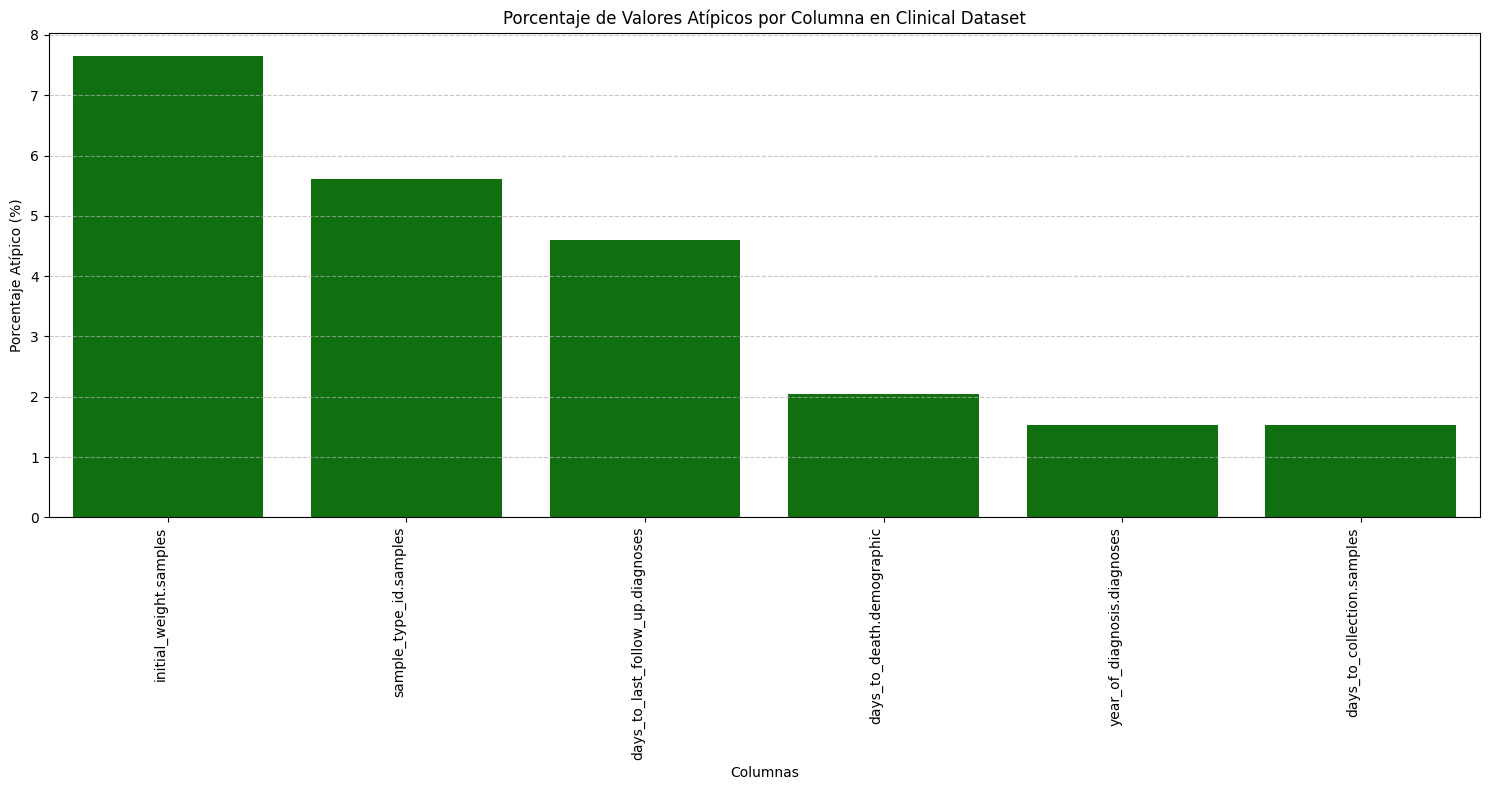

Columnas con valores atípicos y su porcentaje:


,Column,Outlier Percentage
5,initial_weight.samples,7.653061
3,sample_type_id.samples,5.612245
1,days_to_last_follow_up.diagnoses,4.591837
0,days_to_death.demographic,2.040816
2,year_of_diagnosis.diagnoses,1.530612
4,days_to_collection.samples,1.530612


In [58]:
numerical_cols = clinical.select_dtypes(include=['float64', 'int64']).columns
outlier_percentages = {}

for col in numerical_cols:
    Q1 = clinical[col].quantile(0.25)
    Q3 = clinical[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = clinical[(clinical[col] < lower_bound) | (clinical[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(clinical)) * 100
    if outlier_percentage > 0: # Only store columns with at least one outlier
        outlier_percentages[col] = outlier_percentage

# Create a DataFrame for plotting
outlier_df = pd.DataFrame(outlier_percentages.items(), columns=['Column', 'Outlier Percentage']).sort_values(by='Outlier Percentage', ascending=False)

# Define colors based on thresholds
def get_outlier_bar_color(percentage):
    if percentage < 20:
        return 'green'
    elif percentage < 50:
        return 'yellow'
    else:
        return 'red'

colors_outliers = [get_outlier_bar_color(p) for p in outlier_df['Outlier Percentage']]

# Plotting the outlier percentages
plt.figure(figsize=(15, 8))
sns.barplot(x='Column', y='Outlier Percentage', data=outlier_df, palette=colors_outliers)
plt.title('Porcentaje de Valores Atípicos por Columna en Clinical Dataset')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje Atípico (%)')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Columnas con valores atípicos y su porcentaje:")
display(outlier_df)

In [59]:
# imprimir el porcentaje de outliers presentes en el dataset clinical
total_outlier_entries = 0
for col in numerical_cols:
    Q1 = clinical[col].quantile(0.25)
    Q3 = clinical[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = clinical[(clinical[col] < lower_bound) | (clinical[col] > upper_bound)]
    total_outlier_entries += len(outliers)

num_numerical_cells = clinical[numerical_cols].size

overall_outlier_percentage = (total_outlier_entries / num_numerical_cells) * 100 if num_numerical_cells > 0 else 0

print(f"Overall percentage of outlier data points in the clinical dataset: {overall_outlier_percentage:.2f}%")

Overall percentage of outlier data points in the clinical dataset: 1.77%


Bien, buenas noticias, parece que solamente el 2% de los datos del dataset clinico son valores atipicos, no tenemos tantos valores fuera del lugar, como es un porcentaje muy pequeño, podriamos eliminarlo, sin embargo, como estamos tratando con un dataset que procede de algo genetico, lo dejaremos asi, esto ya que no conocemos a fondo esos datos, no sabemos si son un error de captura o si simplemente esta fuera del rango de forma natural, no somos expertos, pero la genetica es extremadamente variable, de modo que para fines practicos, lo dejaremos asi como esta, pero cabe recalcar que siempre es bueno revisar valores fuera del lugar.

Sigamos!

## Transformación de variables
En este apartado vamos a transformar las variables con el objetivo de poder manejarlas mejor, enfocandonos en las variables con distintas clases, las convertiremos de cualitativas a cuantitativas.

In [60]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 68 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     196 non-null    object 
 1   id                                                         196 non-null    object 
 2   disease_type                                               196 non-null    object 
 3   case_id                                                    196 non-null    object 
 4   submitter_id                                               196 non-null    object 
 5   primary_site                                               196 non-null    object 
 6   alcohol_history.exposures                                  196 non-null    object 
 7   race.demographic                                           196 non-null    object 
 8   gender.dem

Sabemos que casi todas nuestras variables del dataset clinico son variables objeto, es decir, tienen varias clases, haremos one hot encoding o binarizarlas, esto lo podemos hacer ya que en aprendizaje no supervisado tenemos la ventaja de que podemos hacer transformaciones sin mucha preocupacion de fuga de datos, ya que lo que queremos precisamente es que el algoritmo / modelo pueda encontrar patrones y agrupar.

In [61]:
# Define the list of identifier columns to be moved
identifier_cols_to_exclude = [
    'pathology_report_uuid.samples', 'sample_id.samples',
    'created_datetime.treatments.diagnoses', 'submitter_id.treatments.diagnoses',
    'treatment_id.treatments.diagnoses', 'updated_datetime.treatments.diagnoses',
    'name.tissue_source_site', 'code.tissue_source_site',
    'tissue_source_site_id.tissue_source_site', 'project_id.project',
    'primary_site.project', 'case_id', 'id', 'submitter_id'
]

# Create a new DataFrame for identifiers
clinical_identifiers = clinical[identifier_cols_to_exclude].copy()

# Drop these identifier columns from the original clinical DataFrame
clinical = clinical.drop(columns=identifier_cols_to_exclude)

print("Shape of clinical_identifiers DataFrame:", clinical_identifiers.shape)
print("Shape of clinical DataFrame after removing identifier columns:", clinical.shape)

print("\nFirst 5 rows of clinical_identifiers:")
display(clinical_identifiers.head())

print("\nFirst 5 rows of clinical after identifier removal:")
display(clinical.head())

Shape of clinical_identifiers DataFrame: (196, 14)
Shape of clinical DataFrame after removing identifier columns: (196, 54)

First 5 rows of clinical_identifiers:


,pathology_report_uuid.samples,sample_id.samples,created_datetime.treatments.diagnoses,submitter_id.treatments.diagnoses,treatment_id.treatments.diagnoses,updated_datetime.treatments.diagnoses,name.tissue_source_site,code.tissue_source_site,tissue_source_site_id.tissue_source_site,project_id.project,primary_site.project,case_id,id,submitter_id
0,66cc897f-570a-4f7d-b134-71ad8066d40e,42ae9a70-ea04-4403-86cc-3da6fd120cde,"['', '2019-04-28T08:50:59.967222-05:00']","['TCGA-HZ-7918_treatment', 'TCGA-HZ-7918_treat...","['6d78550e-0a09-5c77-8114-4ab193decba0', '77b2...","['2019-07-31T15:32:31.211844-05:00', '2019-07-...",International Genomics Consortium,HZ,8fe74cf9-6ff0-50db-b5e0-512d0b054431,TCGA-PAAD,Pancreas,620e0648-ec20-4a12-a6cb-5546fe829c77,620e0648-ec20-4a12-a6cb-5546fe829c77,TCGA-HZ-7918
1,BC3170CA-A046-4D78-9CC6-36C5B70A9C4C,405b467e-41d2-4af1-8544-7b74d36deebd,"['2019-04-28T08:53:50.904263-05:00', '']","['TCGA-3A-A9IS_treatment_1', 'TCGA-3A-A9IS_tre...","['12c5482f-cd89-527d-8a9c-e613993249c5', '57d6...","['2019-07-31T15:35:42.995940-05:00', '2019-07-...",Moffitt Cancer Center,3A,3750e4a2-fc5c-54ba-8be3-53a071217027,TCGA-PAAD,Pancreas,cf825b86-7ec2-4e90-bcce-3b5637b90b70,cf825b86-7ec2-4e90-bcce-3b5637b90b70,TCGA-3A-A9IS
2,803bb8e5-9da4-4f72-92ae-d7cd4152a665,e749babb-81d9-4b12-b7c7-d9c5e4926d1b,"['2019-04-28T08:53:14.318414-05:00', '']","['TCGA-HZ-7924_treatment_1', 'TCGA-HZ-7924_tre...","['105fc558-2d23-511d-9245-8ae185923386', '73ec...","['2019-07-31T15:35:00.763115-05:00', '2019-07-...",International Genomics Consortium,HZ,8fe74cf9-6ff0-50db-b5e0-512d0b054431,TCGA-PAAD,Pancreas,ad220f0d-06b7-4dad-a87d-36dff31c8623,ad220f0d-06b7-4dad-a87d-36dff31c8623,TCGA-HZ-7924
3,64606B7A-008D-459F-8E32-296016364BB1,73caa9fe-4293-4a71-9534-0d5adce937c1,"['', '2019-04-28T08:49:06.729854-05:00']","['TCGA-IB-AAUW_treatment', 'TCGA-IB-AAUW_treat...","['00ba06d7-192a-56e0-9db5-55864e65390e', '57dd...","['2019-07-31T15:30:23.644431-05:00', '2019-07-...",Alberta Health Services,IB,e84a845d-1e5d-5f50-8177-c71af2a77ebc,TCGA-PAAD,Pancreas,18960eb6-2d79-4d12-886a-4cd1e8fc1e21,18960eb6-2d79-4d12-886a-4cd1e8fc1e21,TCGA-IB-AAUW
4,1AB545A6-DC90-47E9-8112-DD094F6BCD02,be6085d3-e73b-4e26-b7d3-f768072592bb,"['2019-04-28T08:52:54.910401-05:00', '']","['TCGA-2J-AABP_treatment_1', 'TCGA-2J-AABP_tre...","['05b7a33d-4ded-534a-b7e6-0536aab365aa', '9300...","['2019-07-31T15:34:38.289162-05:00', '2019-07-...",Mayo Clinic,2J,88ec5169-f4eb-5d61-9136-08ee6ceae4d1,TCGA-PAAD,Pancreas,a4569ce7-dde7-4660-a24c-409d294b2b8c,a4569ce7-dde7-4660-a24c-409d294b2b8c,TCGA-2J-AABP



First 5 rows of clinical after identifier removal:


,sample,disease_type,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,age_at_index.demographic,days_to_birth.demographic,...,tumor_descriptor.samples,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
0,TCGA-HZ-7918-01A,Ductal and Lobular Neoplasms,Pancreas,No,white,male,not hispanic or latino,Alive,72,-26573,...,Primary,Primary Tumor,Not Reported,NaN,NaN,Unknown,NaN,Solid Tissue,False,Tumor
1,TCGA-3A-A9IS-01A,Adenomas and Adenocarcinomas,Pancreas,No,white,male,not hispanic or latino,Alive,67,-24621,...,Primary,Primary Tumor,Not Reported,1141.0,80.0,OCT,True,Solid Tissue,False,Tumor
2,TCGA-HZ-7924-01A,Ductal and Lobular Neoplasms,Pancreas,No,white,female,not hispanic or latino,Alive,60,-22090,...,Primary,Primary Tumor,Not Reported,NaN,NaN,Unknown,NaN,Solid Tissue,False,Tumor
3,TCGA-IB-AAUW-01A,Ductal and Lobular Neoplasms,Pancreas,Yes,white,female,not hispanic or latino,Dead,63,-23306,...,Primary,Primary Tumor,Not Reported,13.0,290.0,OCT,True,Solid Tissue,False,Tumor
4,TCGA-2J-AABP-01A,"Epithelial Neoplasms, NOS",Pancreas,Yes,white,female,not reported,Alive,58,-21484,...,Primary,Primary Tumor,Not Reported,237.0,90.0,OCT,True,Solid Tissue,False,Tumor


En este caso lo que hicimos fue mover ciertas variables a otro dataset, es decir, las quitamos del `clinical` datset, ya que mas que ser variables relevantes, con identificadores, los cuales causan problemas ya que cada una tiene una clase unica, la cual al aplicar one hot encoding se traduce en una nueva variable, lo que nos lleva a tener una variable para cada una de ellas, pero realmente no aportan nada de informacion. por eso, vamos a excluir las siguientes variables ya que son meramente identificadores.

`pathology_report_uuid.samples, sample_id.samples, created_datetime.treatments.diagnoses, submitter_id.treatments.diagnoses, treatment_id.treatments.diagnoses, updated_datetime.treatments.diagnoses,name.tissue_source_site, code.tissue_source_site, tissue_source_site_id.tissue_source_site, project_id.project, primary_site.project, case_id, id, submitter_id`

Ahora, movimos todas excepto `sample`, esto nos servira como identificador para relacionar los datos clinicos con los datos genomicos, por lo que esa columna se quedara pero no se le aplicara one hot encoding

In [62]:
# Identify categorical columns (object and boolean dtypes) in the updated clinical DataFrame
categorical_cols = clinical.select_dtypes(include=['object', 'bool']).columns

# Exclude the 'sample' column from one-hot encoding
categorical_cols_for_ohe = [col for col in categorical_cols if col != 'sample']

print("Categorical columns to be one-hot encoded (excluding 'sample'):", categorical_cols_for_ohe)

# Apply one-hot encoding to these selected categorical columns
clinical_encoded = pd.get_dummies(clinical, columns=categorical_cols_for_ohe, drop_first=False)

# Display the first 5 rows and the new shape of the DataFrame
print("\nShape of DataFrame after one-hot encoding:", clinical_encoded.shape)
print("\nFirst 5 rows of the transformed clinical DataFrame:")
display(clinical_encoded.head())

# Update the clinical DataFrame to the encoded version
clinical = clinical_encoded

Categorical columns to be one-hot encoded (excluding 'sample'): ['disease_type', 'primary_site', 'alcohol_history.exposures', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'disease_type.project', 'name.project', 'name.program.project', 'project.tissue_source_site', 'bcr_id.tissue_source_site', 'synchronous_malignancy.diagnoses', 'ajcc_pathologic_stage.diagnoses', 'last_known_disease_status.diagnoses', 'tissue_or_organ_of_origin.diagnoses', 'primary_diagnosis.diagnoses', 'prior_malignancy.diagnoses', 'prior_treatment.diagnoses', 'ajcc_staging_system_edition.diagnoses', 'ajcc_pathologic_t.diagnoses', 'morphology.diagnoses', 'ajcc_pathologic_n.diagnoses', 'ajcc_pathologic_m.diagnoses', 'classification_of_tumor.diagnoses', 'icd_10_code.diagnoses', 'site_of_resection_or_biopsy.diagnoses', 'tumor_grade.diagnoses', 'progression_or_recurrence.diagnoses', 'treatment_type.treatments.diagnoses', 'state.treatments.diagnoses', 'treatment_or_therapy.t

,sample,age_at_index.demographic,days_to_birth.demographic,year_of_birth.demographic,days_to_death.demographic,days_to_diagnosis.diagnoses,days_to_last_follow_up.diagnoses,age_at_diagnosis.diagnoses,year_of_diagnosis.diagnoses,age_at_earliest_diagnosis.diagnoses.xena_derived,...,composition.samples_Not Reported,preservation_method.samples_OCT,preservation_method.samples_Unknown,oct_embedded.samples_False,oct_embedded.samples_True,specimen_type.samples_Solid Tissue,specimen_type.samples_Unknown,is_ffpe.samples_False,tissue_type.samples_Normal,tissue_type.samples_Tumor
0,TCGA-HZ-7918-01A,72,-26573,1939.0,NaN,0.0,969.0,26573,2011.0,26573.0,...,True,False,True,False,False,True,False,True,False,True
1,TCGA-3A-A9IS-01A,67,-24621,1943.0,NaN,0.0,998.0,24621,2010.0,24621.0,...,True,True,False,False,True,True,False,True,False,True
2,TCGA-HZ-7924-01A,60,-22090,1951.0,NaN,0.0,840.0,22090,2011.0,22090.0,...,True,False,True,False,False,True,False,True,False,True
3,TCGA-IB-AAUW-01A,63,-23306,1950.0,230.0,0.0,179.0,23306,2013.0,23306.0,...,True,True,False,False,True,True,False,True,False,True
4,TCGA-2J-AABP-01A,58,-21484,1955.0,NaN,0.0,463.0,21484,2013.0,21484.0,...,True,True,False,False,True,True,False,True,False,True


In [63]:
# Identify categorical columns (object and boolean dtypes)
categorical_cols = clinical.select_dtypes(include=['object', 'bool']).columns

print("Unique classes for each categorical variable:")
for col in categorical_cols:
    print(f"\nColumn '{col}':")
    print(clinical[col].value_counts())

Unique classes for each categorical variable:

Column 'sample':
sample
TCGA-HZ-7918-01A    1
TCGA-3A-A9IS-01A    1
TCGA-HZ-7924-01A    1
TCGA-IB-AAUW-01A    1
TCGA-2J-AABP-01A    1
                   ..
TCGA-HZ-7925-01A    1
TCGA-2L-AAQJ-01A    1
TCGA-HZ-A77O-01A    1
TCGA-IB-7887-01A    1
TCGA-FB-AAQ1-01A    1
Name: count, Length: 196, dtype: int64

Column 'disease_type_Adenomas and Adenocarcinomas':
disease_type_Adenomas and Adenocarcinomas
False    164
True      32
Name: count, dtype: int64

Column 'disease_type_Cystic, Mucinous and Serous Neoplasms':
disease_type_Cystic, Mucinous and Serous Neoplasms
False    191
True       5
Name: count, dtype: int64

Column 'disease_type_Ductal and Lobular Neoplasms':
disease_type_Ductal and Lobular Neoplasms
True     158
False     38
Name: count, dtype: int64

Column 'disease_type_Epithelial Neoplasms, NOS':
disease_type_Epithelial Neoplasms, NOS
False    195
True       1
Name: count, dtype: int64

Column 'primary_site_Pancreas':
primary_site_Pa

In [64]:
# Re-identify categorical columns from the 'clinical' DataFrame *before* the one-hot encoding step
# (or use clinical_filtered before it was overwritten, if that's more appropriate for debugging)
# Assuming 'clinical_filtered' was the state before the last encoding

# To see the state before the last clinical = clinical_encoded operation, we can check clinical_filtered
# However, since clinical was already overwritten, let's look at the original categorical columns again
# and check their unique values in the pre-encoded 'clinical' or 'clinical_filtered' state.

# Let's get the names of the categorical columns again, before they were encoded
categorical_cols_pre_encoding = clinical_filtered.select_dtypes(include=['object', 'bool']).columns

single_value_cols = []
print("Categorical columns with only one unique value (before one-hot encoding):")
for col in categorical_cols_pre_encoding:
    if clinical_filtered[col].nunique() == 1:
        single_value_cols.append(col)
        print(f"- {col}: {clinical_filtered[col].iloc[0]}")

if not single_value_cols:
    print("No single-value categorical columns found.")
else:
    print(f"\nThese {len(single_value_cols)} columns contribute constant features after one-hot encoding, as they only had one unique value across all samples.")
    print("They might be removed in further preprocessing steps if they don't provide useful information for clustering.")

# Drop the one-hot encoded columns that resulted from single-value categorical columns
# First, identify the specific one-hot encoded columns that will be dropped
dropped_ohe_cols = []
for col in single_value_cols:
    # For a single-value column 'X' with value 'Y', one-hot encoding creates 'X_Y'
    # Boolean columns become 'X_True' or 'X_False'
    if clinical_filtered[col].dtype == 'bool':
        # Assuming the boolean column is like 'is_ffpe.samples', it becomes 'is_ffpe.samples_False'
        val = str(clinical_filtered[col].iloc[0]) # Get the boolean value
        ohe_col_name = f"{col}_{val}"
        if ohe_col_name in clinical.columns:
            dropped_ohe_cols.append(ohe_col_name)
    else:
        # For object columns, we need to handle potential list-like values as well if they were encoded directly
        # But based on the output, these are simple string values or lists of strings for which get_dummies creates a column like 'col_value'
        unique_val = clinical_filtered[col].iloc[0]
        # Handle cases where unique_val might be a list or a simple string
        if isinstance(unique_val, list):
            # If it's a list, pd.get_dummies might create multiple columns or a single column if the list itself is unique
            # This case is tricky with simple `pd.get_dummies` if lists are treated as individual values
            # For the current output, it seems disease_type.project is handled as a single unique list value, resulting in one column.
            # We'll just try to find the direct column name generated by get_dummies for these list types.
            # A safer approach for list-like values is to check if the column name exists in `clinical.columns`
            str_unique_val = str(unique_val) # get_dummies might encode lists as strings
            ohe_col_name = f"{col}_{str_unique_val}"
            if ohe_col_name in clinical.columns:
                dropped_ohe_cols.append(ohe_col_name)
            # Also check for individual elements of the list being encoded if get_dummies exploded them
            for item in unique_val:
                ohe_col_name_item = f"{col}_{str(item)}"
                if ohe_col_name_item in clinical.columns and ohe_col_name_item not in dropped_ohe_cols:
                    dropped_ohe_cols.append(ohe_col_name_item)

        else:
            ohe_col_name = f"{col}_{str(unique_val)}"
            if ohe_col_name in clinical.columns:
                dropped_ohe_cols.append(ohe_col_name)
            # Special handling for single-value columns that might have values like 'not reported' or 'Not Reported'
            # For example, 'composition.samples': 'Not Reported'
            # 'last_known_disease_status.diagnoses': 'not reported'
            # 'tumor_grade.diagnoses': 'Not Reported'
            # It's possible get_dummies normalizes these or they are taken literally.
            # The print statement above ensures we get the exact string value.


# Ensure no duplicates in the list of columns to drop
dropped_ohe_cols = list(set(dropped_ohe_cols))

print(f"\nOne-hot encoded columns to be dropped due to single unique value: {len(dropped_ohe_cols)}")
print(dropped_ohe_cols)

# Drop these columns from the clinical DataFrame
clinical = clinical.drop(columns=dropped_ohe_cols, errors='ignore')

print(f"\nNew shape of clinical DataFrame after removing constant OHE columns: {clinical.shape}")

Categorical columns with only one unique value (before one-hot encoding):
- primary_site: Pancreas
- primary_site.project: Pancreas
- project_id.project: TCGA-PAAD
- disease_type.project: ['Cystic, Mucinous and Serous Neoplasms', 'Ductal and Lobular Neoplasms', 'Adenomas and Adenocarcinomas', 'Epithelial Neoplasms, NOS']
- name.project: Pancreatic Adenocarcinoma
- name.program.project: TCGA
- project.tissue_source_site: Pancreatic adenocarcinoma
- synchronous_malignancy.diagnoses: No
- last_known_disease_status.diagnoses: not reported
- classification_of_tumor.diagnoses: not reported
- tumor_grade.diagnoses: Not Reported
- progression_or_recurrence.diagnoses: not reported
- state.treatments.diagnoses: ['released', 'released']
- composition.samples: Not Reported
- is_ffpe.samples: False

These 15 columns contribute constant features after one-hot encoding, as they only had one unique value across all samples.
They might be removed in further preprocessing steps if they don't provide use

In [65]:
# Convert boolean columns to integer (0 or 1)
for col in clinical.select_dtypes(include=['bool']).columns:
    clinical[col] = clinical[col].astype(int)

# Define columns to be dropped as they are redundant or less informative
columns_to_drop_further = [
    'days_to_birth.demographic',
    'days_to_diagnosis.diagnoses',
    'age_at_diagnosis.diagnoses',
    'age_at_earliest_diagnosis.diagnoses.xena_derived'
]

# Drop the specified columns
clinical = clinical.drop(columns=columns_to_drop_further, errors='ignore')

print("Shape of clinical DataFrame after boolean conversion and dropping additional columns:", clinical.shape)
print("\nFirst 5 rows of the modified clinical DataFrame:")
display(clinical.head())

Shape of clinical DataFrame after boolean conversion and dropping additional columns: (196, 107)

First 5 rows of the modified clinical DataFrame:


,sample,age_at_index.demographic,year_of_birth.demographic,days_to_death.demographic,days_to_last_follow_up.diagnoses,year_of_diagnosis.diagnoses,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,sample_type_id.samples,days_to_collection.samples,initial_weight.samples,...,sample_type.samples_Primary Tumor,sample_type.samples_Solid Tissue Normal,preservation_method.samples_OCT,preservation_method.samples_Unknown,oct_embedded.samples_False,oct_embedded.samples_True,specimen_type.samples_Solid Tissue,specimen_type.samples_Unknown,tissue_type.samples_Normal,tissue_type.samples_Tumor
0,TCGA-HZ-7918-01A,72,1939.0,NaN,969.0,2011.0,72.802740,1,NaN,NaN,...,1,0,0,1,0,0,1,0,0,1
1,TCGA-3A-A9IS-01A,67,1943.0,NaN,998.0,2010.0,67.454795,1,1141.0,80.0,...,1,0,1,0,0,1,1,0,0,1
2,TCGA-HZ-7924-01A,60,1951.0,NaN,840.0,2011.0,60.520548,1,NaN,NaN,...,1,0,0,1,0,0,1,0,0,1
3,TCGA-IB-AAUW-01A,63,1950.0,230.0,179.0,2013.0,63.852055,1,13.0,290.0,...,1,0,1,0,0,1,1,0,0,1
4,TCGA-2J-AABP-01A,58,1955.0,NaN,463.0,2013.0,58.860274,1,237.0,90.0,...,1,0,1,0,0,1,1,0,0,1


In [66]:
# verificar que ahora tenemos solo numeros en el dataset
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Columns: 107 entries, sample to tissue_type.samples_Tumor
dtypes: float64(7), int64(99), object(1)
memory usage: 164.0+ KB


Perfecto, ahora vemos que tenemos 106 columnas tipo numero y 1 variable categorica, la cual es el ID que usaremos posterioremente

## Reducción de dimensiones PCA
Ahora, ya que el dataset clinico esta limpio y listo con las transformaciones correspondientes, vamos a reducir las dimensiones del dataset genetico, ya que son casi 60,700 observaciones y ,multiples columnas (184), lo cual es mucha informacion, la cual convendria reducir

In [67]:
tpm.shape

(60660, 184)

### Preparación y Transformación de Datos `tpm` para PCA

Antes de aplicar PCA, necesitamos preparar los datos de expresión génica (`tpm`). Esto incluye:
1.  Establecer la columna `Ensembl_ID` como índice para identificar los genes.
2.  Transponer el DataFrame para que las muestras sean filas y los genes sean columnas, ya que PCA generalmente opera sobre las muestras.
3.  Aplicar una transformación logarítmica (`log2(TPM + 0.001)`) para normalizar la distribución de los valores de expresión, como se mencionó anteriormente.
4.  Manejar posibles valores nulos (aunque se asume que no hay en los valores de TPM después de la carga).

Luego, estandarizaremos los datos para que cada gen (columna) tenga una media de 0 y una desviación estándar de 1. Esto es crucial para que PCA no le dé un peso desproporcionado a genes con mayor varianza inicial.

In [68]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy to avoid modifying the original tpm DataFrame directly for this step
tpm_processed = tpm.copy()

# Set Ensembl_ID as index
tpm_processed = tpm_processed.set_index('Ensembl_ID')

# Transpose the DataFrame: samples as rows, genes as columns
tpm_processed = tpm_processed.T

# Apply log2 transformation to gene expression values
# Add a small constant (0.001) to avoid log(0)
tpm_processed = np.log2(tpm_processed + 0.001)

print("Shape of TPM data after processing and transposing:", tpm_processed.shape)
display(tpm_processed.head())

Shape of TPM data after processing and transposing: (183, 60660)


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-IB-A6UG-01A,2.364527,-9.965784,2.538034,1.391150,0.544890,1.437319,2.088570,2.443317,1.687393,2.045719,...,-9.965784,-9.965784,-1.141864,-9.965784,-9.965784,-9.965784,1.415971,-9.965784,-4.504240,0.398303
TCGA-3A-A9IU-01A,2.517664,-3.995228,2.689772,1.705073,1.094274,1.682826,2.672723,2.412706,1.679478,2.232402,...,-9.965784,-9.965784,-1.423381,-9.965784,-9.965784,-9.965784,1.858528,-9.965784,-3.548396,-0.228709
TCGA-FB-A545-01A,2.222921,-9.965784,2.729394,1.567821,1.152890,0.876371,2.252279,2.488954,1.826968,2.241876,...,-9.965784,-9.965784,-0.565863,-9.965784,-9.965784,-9.965784,1.690145,-9.965784,-3.745724,0.448202
TCGA-IB-AAUQ-01A,2.148850,-1.724575,2.617004,1.428761,0.840345,1.635427,2.617909,2.603113,2.012123,2.104247,...,-9.965784,0.358080,-1.600680,-9.965784,-9.965784,-9.965784,1.570952,-9.965784,-4.276313,0.820818
TCGA-HV-A5A3-01A,2.354724,-9.965784,2.755018,1.869414,1.225766,2.044457,2.765468,2.106837,1.532752,2.353176,...,-9.965784,0.605111,-1.123223,-9.965784,-9.965784,-9.965784,1.829131,-9.965784,-9.965784,-0.437472


### Estandarización de los Datos `tpm`

La estandarización es un paso crítico antes de aplicar PCA, ya que PCA es sensible a la escala de las características. `StandardScaler` transformará los datos de tal manera que cada característica (gen) tenga una media de 0 y una varianza de 1.

In [69]:
# Initialize StandardScaler
scaler = StandardScaler()

# Standardize the data
tpm_scaled = scaler.fit_transform(tpm_processed)

# Convert the scaled data back to a DataFrame for easier handling, preserving sample IDs and gene names
tpm_scaled_df = pd.DataFrame(tpm_scaled, index=tpm_processed.index, columns=tpm_processed.columns)

print("Shape of standardized TPM data:", tpm_scaled_df.shape)
display(tpm_scaled_df.head())

Shape of standardized TPM data: (183, 60660)


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-IB-A6UG-01A,0.489076,-1.454959,-0.973552,-0.579928,-0.515510,-0.883412,-0.752468,-0.609853,-0.433147,-0.456254,...,-2.309264e-14,-0.340087,0.486738,-2.309264e-14,-0.406546,-0.413637,-0.822244,-2.309264e-14,0.047862,0.711748
TCGA-3A-A9IU-01A,0.934702,0.069259,0.316993,0.540258,0.741931,-0.405381,0.661334,-0.871084,-0.463838,0.390058,...,-2.309264e-14,-0.340087,0.236805,-2.309264e-14,-0.406546,-0.413637,0.851397,-2.309264e-14,0.715269,-0.472447
TCGA-FB-A545-01A,0.077007,-1.454959,0.653991,0.050497,0.876091,-1.975645,-0.356251,-0.220396,0.108052,0.433007,...,-2.309264e-14,-0.340087,0.998116,-2.309264e-14,-0.406546,-0.413637,0.214614,-2.309264e-14,0.577486,0.805990
TCGA-IB-AAUQ-01A,-0.138537,0.648931,-0.301904,-0.445717,0.160734,-0.497672,0.528670,0.753819,0.825984,-0.190924,...,-2.309264e-14,2.949048,0.079397,-2.309264e-14,-0.406546,-0.413637,-0.236145,-2.309264e-14,0.207009,1.509724
TCGA-HV-A5A3-01A,0.460550,-1.454959,0.871923,1.126686,1.042893,0.298757,0.885801,-3.481314,-1.032765,0.937576,...,-2.309264e-14,3.027750,0.503287,-2.309264e-14,-0.406546,-0.413637,0.740223,-2.309264e-14,-3.765595,-0.866726


### Aplicación de PCA y Análisis de Varianza Explicada

Ahora aplicaremos PCA a los datos estandarizados. Primero, ejecutaremos PCA sin especificar un número de componentes para evaluar la varianza explicada por cada componente principal. Esto nos ayudará a decidir cuántos componentes son necesarios para capturar una cantidad significativa de la varianza total de los datos.

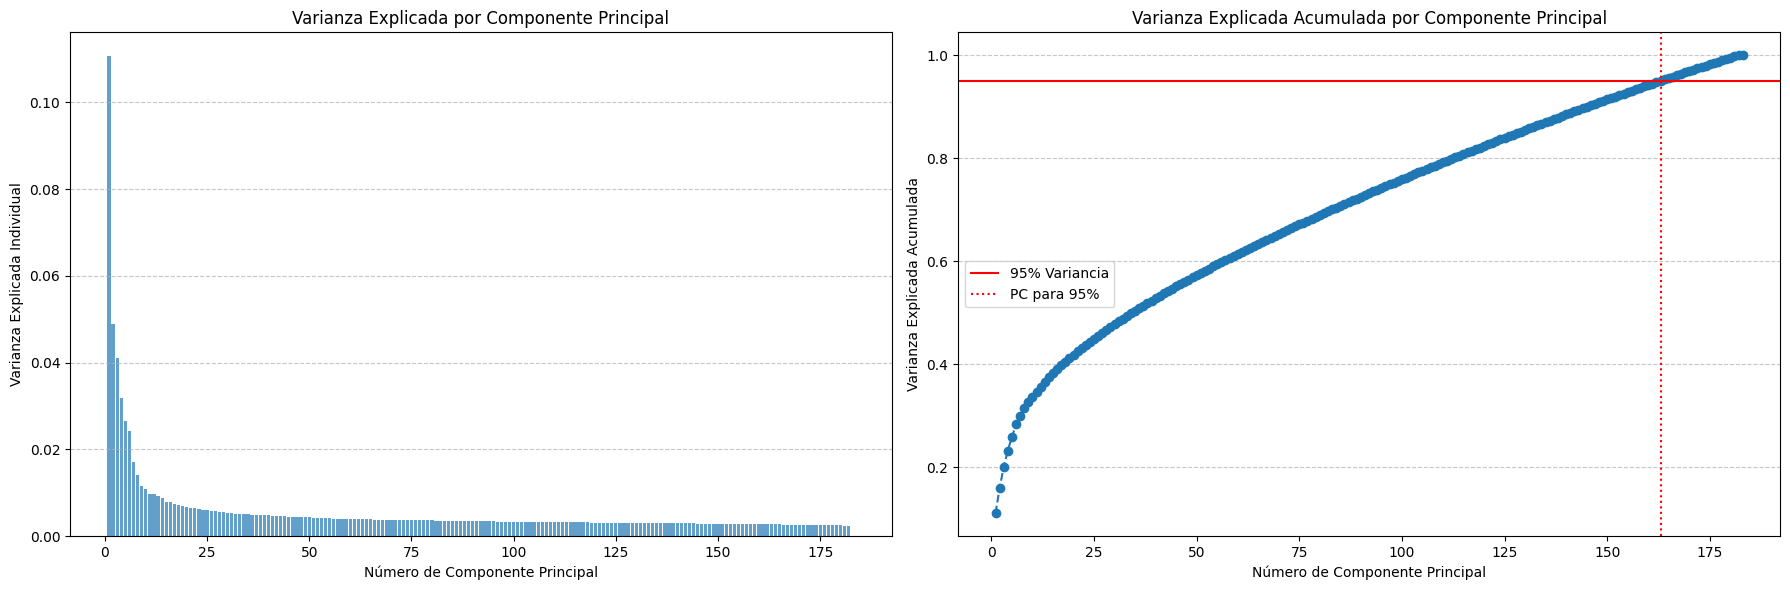

Number of components to explain 95% of variance: 163


In [70]:
# Initialize PCA - keeping all components for initial analysis
pca = PCA()

# Fit PCA to the scaled data
pca.fit(tpm_scaled)

# Calculate explained variance ratios
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plotting the explained variance
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7)
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada Individual')
plt.title('Varianza Explicada por Componente Principal')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por Componente Principal')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variancia') # Example threshold
plt.axvline(x=np.argmax(cumulative_explained_variance >= 0.95) + 1, color='r', linestyle=':', label='PC para 95%')
plt.legend()
plt.tight_layout()
plt.show()

# Print the number of components to explain 95% of variance
num_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components to explain 95% of variance: {num_components_95}")

Bien, al parecer necesitamos 163 PC's para explicar el 95% de la varianza de los datos, pero vamos a ver si podemos simplificarlo un poco mas, ya que la grafica de la izquierda (elbow chart), nos dice que la varianza individual explicada pasa a ser casi la misma a partir del decimo componente principal (aproximadamente), asi que veamos que tal nos va con 10 PC.

### Distribución de los Componentes Principales Más Significativos

Para entender mejor la estructura de los datos después de PCA, visualizaremos la distribución de los primeros componentes principales. Esto nos puede dar una idea de si los datos se agrupan o si hay distribuciones sesgadas en las nuevas dimensiones.

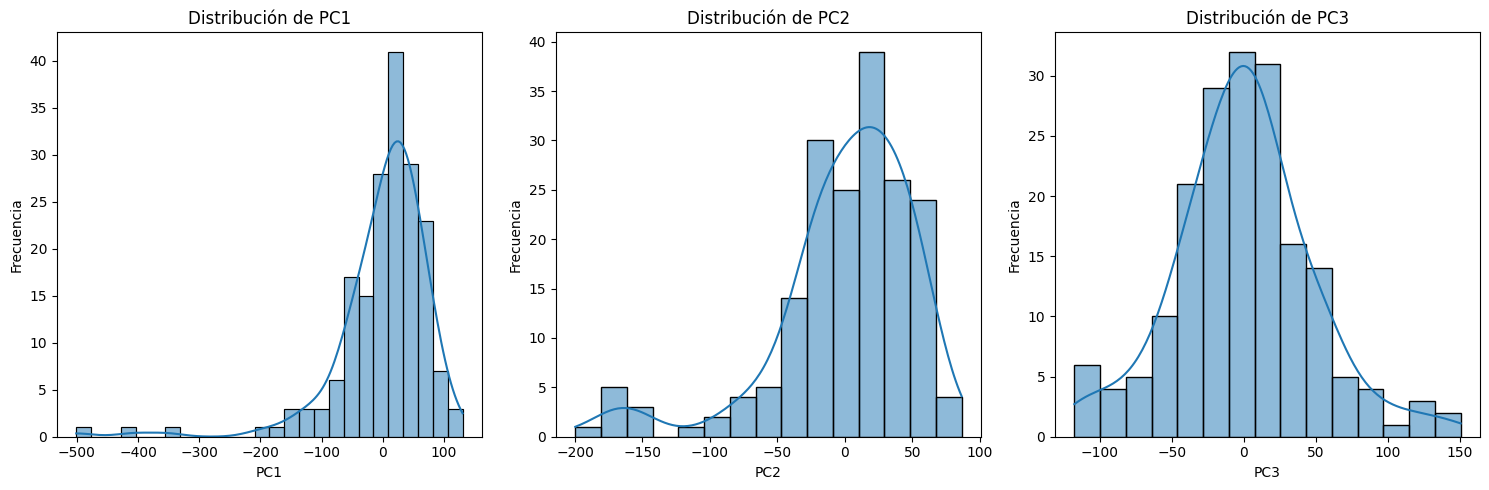

First 5 rows of Principal Components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC174,PC175,PC176,PC177,PC178,PC179,PC180,PC181,PC182,PC183
TCGA-IB-A6UG-01A,-37.850331,-4.326308,6.752700,43.447203,-32.350158,-8.117820,-7.597970,15.615302,-19.267374,43.705001,...,-1.527220,4.127427,0.727427,-2.635679,-4.917360,0.388159,3.255571,-5.900364,0.533583,-6.813653e-15
TCGA-3A-A9IU-01A,20.600272,36.037506,16.074002,4.329803,-14.964060,1.900830,-24.694513,26.366162,-1.326169,35.275815,...,1.206893,-4.970841,3.896489,-9.418388,4.109901,-12.668885,-1.645167,-2.231808,0.503284,6.625810e-14
TCGA-FB-A545-01A,42.961383,38.819530,58.466271,2.808945,-4.746333,16.899615,-51.542875,54.963287,-5.071569,-43.371444,...,0.076351,0.722236,0.271285,-0.067189,-2.448923,1.383331,-0.791618,1.167245,-0.450330,5.026395e-14
TCGA-IB-AAUQ-01A,24.880618,-3.548913,6.940036,22.679182,-2.006389,35.023222,-5.515605,11.687468,-7.839101,10.577497,...,0.930565,-2.179194,4.405485,-4.758081,0.420012,1.554986,1.157747,-0.168564,2.911968,3.205630e-14
TCGA-HV-A5A3-01A,-12.923230,59.660546,44.111102,-2.598866,-28.941977,14.930693,-52.782847,16.613113,13.654847,-19.453981,...,1.631487,0.177448,-3.453925,-5.345418,-3.492318,-0.519558,9.202315,3.799267,-2.530784,6.438981e-14


In [71]:
# Transform the scaled data using PCA to get the principal components
tpm_pca = pca.transform(tpm_scaled)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(data=tpm_pca, index=tpm_processed.index, columns=[f'PC{i+1}' for i in range(tpm_pca.shape[1])])

# Plot distributions of the first few principal components (e.g., PC1, PC2, PC3)
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    sns.histplot(pca_df[f'PC{i+1}'], kde=True)
    plt.title(f'Distribución de PC{i+1}')
    plt.xlabel(f'PC{i+1}')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print("First 5 rows of Principal Components:")
display(pca_df.head())

### Reducción a 10 PC

In [72]:
# Re-initialize PCA with 10 components
pca_10_components = PCA(n_components=10)

# Fit and transform the scaled TPM data
tpm_pca_10 = pca_10_components.fit_transform(tpm_scaled)

# Create a DataFrame for the 10 principal components
pca_df_10 = pd.DataFrame(data=tpm_pca_10, index=tpm_processed.index, columns=[f'PC{i+1}' for i in range(10)])

print("Shape of TPM data after reducing to 10 Principal Components:", pca_df_10.shape)
print("First 5 rows of 10 Principal Components:")
display(pca_df_10.head())

Shape of TPM data after reducing to 10 Principal Components: (183, 10)
First 5 rows of 10 Principal Components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
TCGA-IB-A6UG-01A,-37.850331,-4.326314,6.752692,43.447251,-32.350033,-8.118196,-7.596455,15.524671,-19.005150,44.411295
TCGA-3A-A9IU-01A,20.600272,36.037510,16.074019,4.329874,-14.964265,1.901253,-24.697750,26.387834,-1.610417,34.985373
TCGA-FB-A545-01A,42.961383,38.819487,58.466273,2.809318,-4.745877,16.896211,-51.536149,54.611119,-3.460316,-41.022394
TCGA-IB-AAUQ-01A,24.880618,-3.548904,6.940056,22.679222,-2.006431,35.024281,-5.515849,11.769363,-8.114243,10.062102
TCGA-HV-A5A3-01A,-12.923230,59.660534,44.111123,-2.598778,-28.941954,14.931540,-52.788006,16.435581,14.008704,-18.949805


### Scatter Plot de los 2 Primeros Componentes Principales (Reducido a 10 PC)

Vamos a visualizar la separación o agrupamiento de las muestras utilizando los dos primeros componentes principales de este conjunto de 10 PCs.

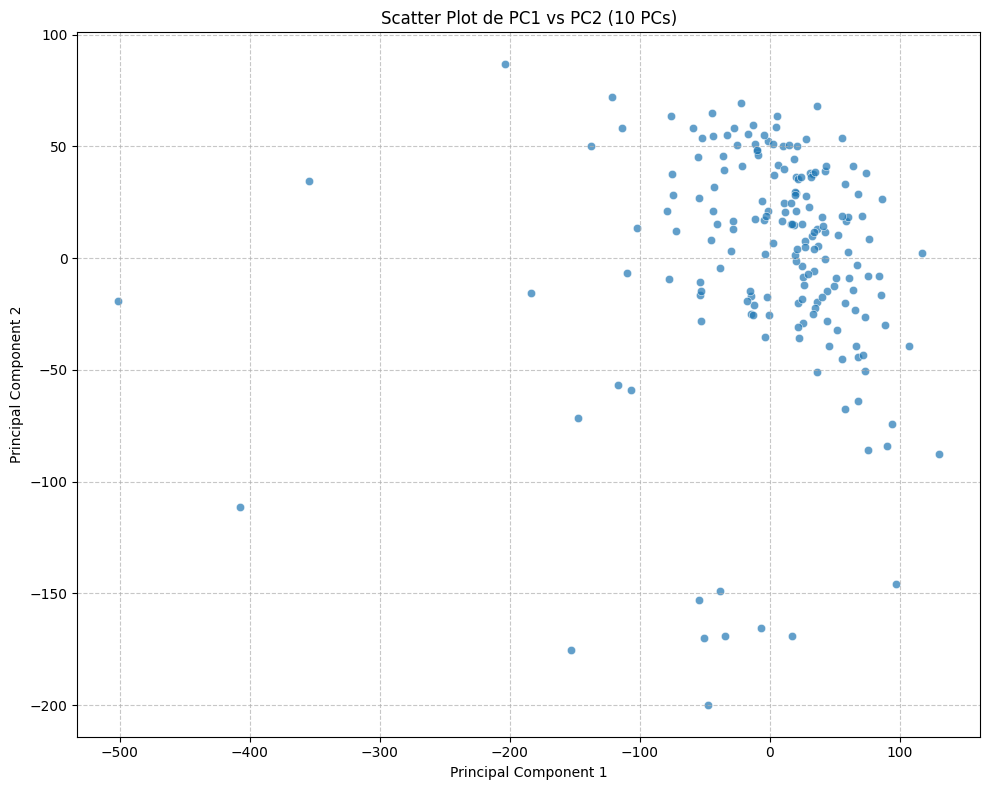

In [73]:
# Scatter plot of the first two principal components from the 10-PC reduction
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=pca_df_10, alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot de PC1 vs PC2 (10 PCs)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Se observa una acumulacion de los datos en el scatter PCA, probemos con los modelos para ver que tal nos va agrupando.

# Clustering - k-means

### Determinación del Número Óptimo de Clústeres (K) con los Métodos del Codo y Silhouette

Seleccionar el número adecuado de clústeres ($K$) es un paso crucial en el clustering. Utilizaremos dos métodos populares:

1.  **Método del Codo (Elbow Method)**: Este método busca identificar el valor de $K$ donde la adición de otro clúster no mejora significativamente la inercia (suma de las distancias cuadradas de cada punto a su centroide asignado). Se visualiza graficando la inercia para diferentes valores de $K$ y buscando un 'codo' en la curva.
2.  **Coeficiente de Silhouette**: Este método mide qué tan similar es un objeto a su propio clúster (cohesión) en comparación con otros clústeres (separación). Los valores de Silhouette oscilan entre -1 y 1. Un valor cercano a 1 indica que el objeto está bien emparejado con su propio clúster y mal emparejado con clústeres vecinos. Un valor cercano a 0 indica que el objeto está en el límite entre dos clústeres. Valores negativos indican que el objeto podría haber sido asignado al clúster incorrecto.

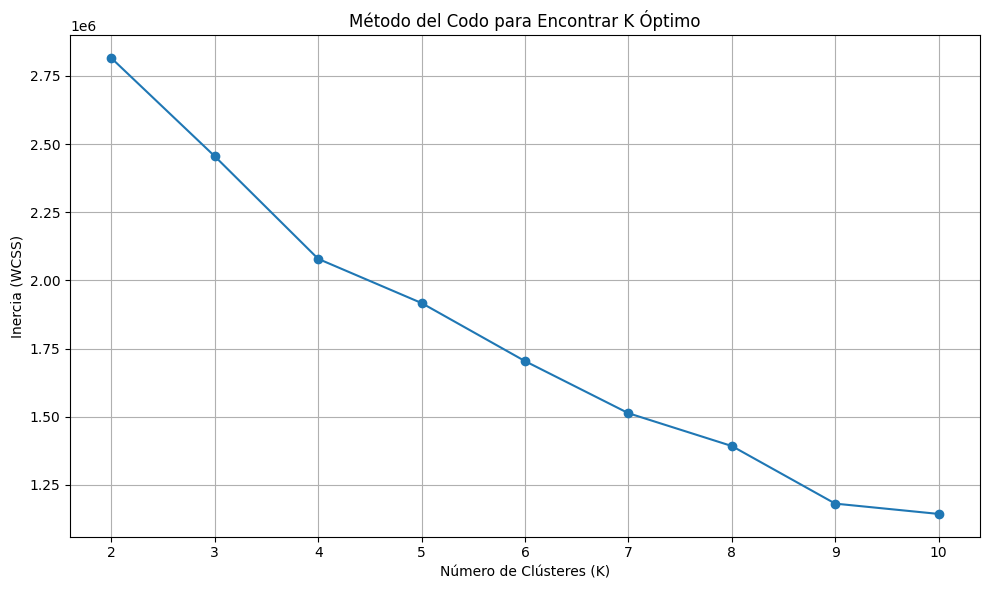

Interpretación del Método del Codo: Busque el punto en la gráfica donde la disminución en la inercia comienza a ralentizarse significativamente, formando un 'codo'.


In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define a range of K values to test
k_range = range(2, 11)  # Test from 2 to 10 clusters

# --- Elbow Method ---
inertia = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is important for robust results
    kmeans.fit(pca_df_10)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.show()

print("Interpretación del Método del Codo: Busque el punto en la gráfica donde la disminución en la inercia comienza a ralentizarse significativamente, formando un 'codo'.")

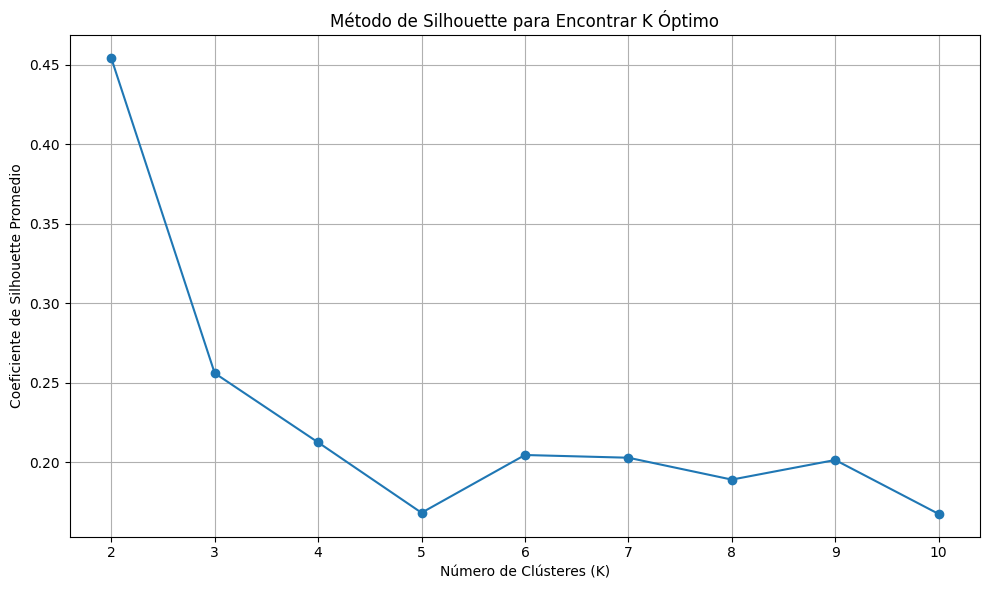

Interpretación del Método de Silhouette: El valor de K con el coeficiente de Silhouette más alto es generalmente el número óptimo de clústeres.
Para K = 2, Coeficiente de Silhouette = 0.4540
Para K = 3, Coeficiente de Silhouette = 0.2559
Para K = 4, Coeficiente de Silhouette = 0.2124
Para K = 5, Coeficiente de Silhouette = 0.1681
Para K = 6, Coeficiente de Silhouette = 0.2044
Para K = 7, Coeficiente de Silhouette = 0.2027
Para K = 8, Coeficiente de Silhouette = 0.1890
Para K = 9, Coeficiente de Silhouette = 0.2013
Para K = 10, Coeficiente de Silhouette = 0.1674


In [75]:
# --- Silhouette Method ---
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_df_10)
    score = silhouette_score(pca_df_10, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Método de Silhouette para Encontrar K Óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Coeficiente de Silhouette Promedio')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.show()

print("Interpretación del Método de Silhouette: El valor de K con el coeficiente de Silhouette más alto es generalmente el número óptimo de clústeres.")

# Display the scores for easy comparison
for k, score in zip(k_range, silhouette_scores):
    print(f"Para K = {k}, Coeficiente de Silhouette = {score:.4f}")

### Realización del Clustering K-Means con K Óptimo

Ahora que hemos determinado el número óptimo de clústeres ($K=2$) usando el método de Silhouette, procederemos a aplicar el algoritmo K-Means a los datos reducidos por PCA (`pca_df_10`). Esto nos dará la asignación final de cada muestra a un clúster.

K-Means clustering completed with 2 clusters.
Primeras 5 asignaciones de clústeres:
[1 1 1 1 1]
Centroides finales (primeras 5 filas):
[[-135.75054392  -59.0191254    24.76577769  -21.52663083   -7.27889405
    -6.23954675   -1.06175238   -4.11550388   -6.10897249   -1.44658506]
 [  19.51414069    8.48399928   -3.56008054    3.09445318    1.04634102
     0.89693485    0.1526269     0.59160368    0.8781648     0.2079466 ]]


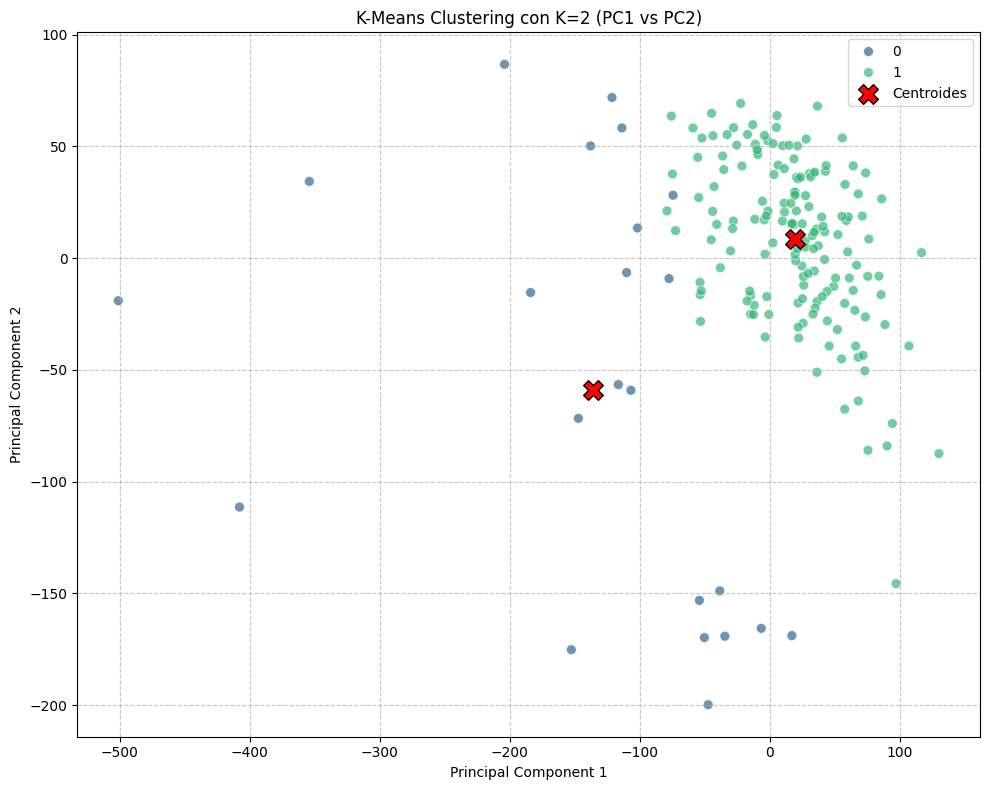

In [76]:
# Initialize and run K-Means with K=2
k_optimal = 2
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_final.fit(pca_df_10)

# Get cluster labels and centroids
cluster_labels = kmeans_final.labels_
final_centroids = kmeans_final.cluster_centers_

print(f"K-Means clustering completed with {k_optimal} clusters.")
print("Primeras 5 asignaciones de clústeres:")
print(cluster_labels[:5])
print("Centroides finales (primeras 5 filas):")
print(final_centroids[:5])

# Visualize the final clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue=cluster_labels, palette='viridis', data=pca_df_10, legend='full', s=50, alpha=0.7)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], marker='X', s=200, color='red', label='Centroides', edgecolors='black')
plt.title(f'K-Means Clustering con K={k_optimal} (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Evaluación de la Calidad del Clustering

Ahora que hemos realizado el clustering, es importante evaluar su calidad. Además del coeficiente de Silhouette que ya calculamos para la selección de K, podemos reconfirmar su valor para el número de clústeres elegido. También es útil calcular la inercia del modelo final.

In [77]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for the final clustering
silhouette_avg = silhouette_score(pca_df_10, cluster_labels)
print(f"Coeficiente de Silhouette para K={k_optimal}: {silhouette_avg:.4f}")

# Get the inertia for the final clustering
final_inertia = kmeans_final.inertia_
print(f"Inercia (WCSS) para K={k_optimal}: {final_inertia:.2f}")

Coeficiente de Silhouette para K=2: 0.4540
Inercia (WCSS) para K=2: 2815416.13


## Integración de Clústeres con Datos Clínicos

Con los clústeres de pacientes ya definidos a partir de los datos de expresión génica, el siguiente paso es integrar esta información con los datos clínicos (`clinical`). Esto nos permitirá caracterizar cada clúster en términos de variables clínicas como edad, género, estadio de la enfermedad y supervivencia, buscando asociaciones que puedan tener relevancia biológica o pronóstica.

In [78]:
# Add cluster labels to the pca_df_10 DataFrame
pca_df_10['cluster'] = cluster_labels

# The sample IDs are the index of pca_df_10, so we need to reset index to merge on 'sample'
pca_df_with_clusters = pca_df_10.reset_index()
pca_df_with_clusters = pca_df_with_clusters.rename(columns={'index': 'sample'})

# Ensure 'sample' column in pca_df_with_clusters has the '-01A' suffix removed (already done in previous version, keeping for clarity)
pca_df_with_clusters['sample'] = pca_df_with_clusters['sample'].apply(lambda x: x[:-4] if x.endswith('-01A') else x)

# --- FIX START: Correcting the merge logic ---

# Prepare the 'clinical' DataFrame for merging
# First, let's ensure the 'sample' column in the 'clinical' DataFrame is in the same format
# as the 'sample' column in 'pca_df_with_clusters' (i.e., without the '-01A' suffix).
clinical_for_merge = clinical.copy()
clinical_for_merge['sample'] = clinical_for_merge['sample'].apply(lambda x: x[:-4] if x.endswith('-01A') else x)

# Now, merge the pca_df_with_clusters (containing PCs and cluster labels) with the prepared clinical data.
# We will merge on the 'sample' column which now acts as our common patient identifier.
final_merged_data = pd.merge(pca_df_with_clusters,
                             clinical_for_merge,
                             left_on='sample',
                             right_on='sample',
                             how='inner')

# --- FIX END ---

print("Shape of merged data with clinical and cluster information:", final_merged_data.shape)
print("First 5 rows of merged data:")
display(final_merged_data.head())

Shape of merged data with clinical and cluster information: (183, 118)
First 5 rows of merged data:


,sample,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,sample_type.samples_Primary Tumor,sample_type.samples_Solid Tissue Normal,preservation_method.samples_OCT,preservation_method.samples_Unknown,oct_embedded.samples_False,oct_embedded.samples_True,specimen_type.samples_Solid Tissue,specimen_type.samples_Unknown,tissue_type.samples_Normal,tissue_type.samples_Tumor
0,TCGA-IB-A6UG,-37.850331,-4.326314,6.752692,43.447251,-32.350033,-8.118196,-7.596455,15.524671,-19.005150,...,1,0,1,0,0,1,1,0,0,1
1,TCGA-3A-A9IU,20.600272,36.037510,16.074019,4.329874,-14.964265,1.901253,-24.697750,26.387834,-1.610417,...,1,0,1,0,0,1,1,0,0,1
2,TCGA-FB-A545,42.961383,38.819487,58.466273,2.809318,-4.745877,16.896211,-51.536149,54.611119,-3.460316,...,1,0,1,0,0,1,1,0,0,1
3,TCGA-IB-AAUQ,24.880618,-3.548904,6.940056,22.679222,-2.006431,35.024281,-5.515849,11.769363,-8.114243,...,1,0,1,0,0,1,1,0,0,1
4,TCGA-HV-A5A3,-12.923230,59.660534,44.111123,-2.598778,-28.941954,14.931540,-52.788006,16.435581,14.008704,...,1,0,0,1,1,0,1,0,0,1


# Diferenciar clusters

### Identificación y Visualización de Genes Diferencialmente Expresados

In [79]:
from scipy.stats import ttest_ind

# Ensure the indices match before merging
# The 'sample' column in `pca_df_10` was created from the index of `tpm_processed`, which matches `tpm_scaled_df`'s index.
# We need to explicitly reset the index of `pca_df_10` if it was modified, or directly map the 'cluster' labels.

# Create a mapping from sample ID to cluster label
cluster_mapping = pca_df_10['cluster'].to_dict()

# Add the cluster labels to the tpm_scaled_df
tpm_with_clusters = tpm_scaled_df.copy()
tpm_with_clusters['cluster'] = tpm_with_clusters.index.map(cluster_mapping)

# Drop samples that might not have a cluster assignment (shouldn't happen if indices align)
tpm_with_clusters.dropna(subset=['cluster'], inplace=True)
tpm_with_clusters['cluster'] = tpm_with_clusters['cluster'].astype(int)

print("Shape of TPM data with cluster labels:", tpm_with_clusters.shape)
display(tpm_with_clusters.head())

Shape of TPM data with cluster labels: (183, 60661)


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,cluster
TCGA-IB-A6UG-01A,0.489076,-1.454959,-0.973552,-0.579928,-0.515510,-0.883412,-0.752468,-0.609853,-0.433147,-0.456254,...,-0.340087,0.486738,-2.309264e-14,-0.406546,-0.413637,-0.822244,-2.309264e-14,0.047862,0.711748,1
TCGA-3A-A9IU-01A,0.934702,0.069259,0.316993,0.540258,0.741931,-0.405381,0.661334,-0.871084,-0.463838,0.390058,...,-0.340087,0.236805,-2.309264e-14,-0.406546,-0.413637,0.851397,-2.309264e-14,0.715269,-0.472447,1
TCGA-FB-A545-01A,0.077007,-1.454959,0.653991,0.050497,0.876091,-1.975645,-0.356251,-0.220396,0.108052,0.433007,...,-0.340087,0.998116,-2.309264e-14,-0.406546,-0.413637,0.214614,-2.309264e-14,0.577486,0.805990,1
TCGA-IB-AAUQ-01A,-0.138537,0.648931,-0.301904,-0.445717,0.160734,-0.497672,0.528670,0.753819,0.825984,-0.190924,...,2.949048,0.079397,-2.309264e-14,-0.406546,-0.413637,-0.236145,-2.309264e-14,0.207009,1.509724,1
TCGA-HV-A5A3-01A,0.460550,-1.454959,0.871923,1.126686,1.042893,0.298757,0.885801,-3.481314,-1.032765,0.937576,...,3.027750,0.503287,-2.309264e-14,-0.406546,-0.413637,0.740223,-2.309264e-14,-3.765595,-0.866726,1


### Heatmap de los Top 50 Genes Más Diferenciales entre Clústeres

Se han seleccionado los siguientes 50 genes con mayor diferencia de expresión entre los clusters 0 y 1:


Index(['ENSG00000137693.14', 'ENSG00000145623.13', 'ENSG00000070190.13',
       'ENSG00000067066.17', 'ENSG00000114978.18', 'ENSG00000023445.16',
       'ENSG00000156869.14', 'ENSG00000175115.13', 'ENSG00000148484.18',
       'ENSG00000166889.14', 'ENSG00000024422.12', 'ENSG00000163466.16',
       'ENSG00000073921.18', 'ENSG00000144118.14', 'ENSG00000035403.18',
       'ENSG00000061273.18', 'ENSG00000003402.20', 'ENSG00000121964.14',
       'ENSG00000163565.19', 'ENSG00000071054.16', 'ENSG00000185650.10',
       'ENSG00000162976.13', 'ENSG00000150782.12', 'ENSG00000116489.13',
       'ENSG00000171055.15', 'ENSG00000149115.14', 'ENSG00000112079.9',
       'ENSG00000196083.10', 'ENSG00000140299.13', 'ENSG00000154237.13',
       'ENSG00000153250.20', 'ENSG00000173039.19', 'ENSG00000099139.14',
       'ENSG00000064012.22', 'ENSG00000064666.15', 'ENSG00000103966.11',
       'ENSG00000160691.19', 'ENSG00000163162.9', 'ENSG00000067082.15',
       'ENSG00000147065.17', 'ENSG00000146112.12', 'E

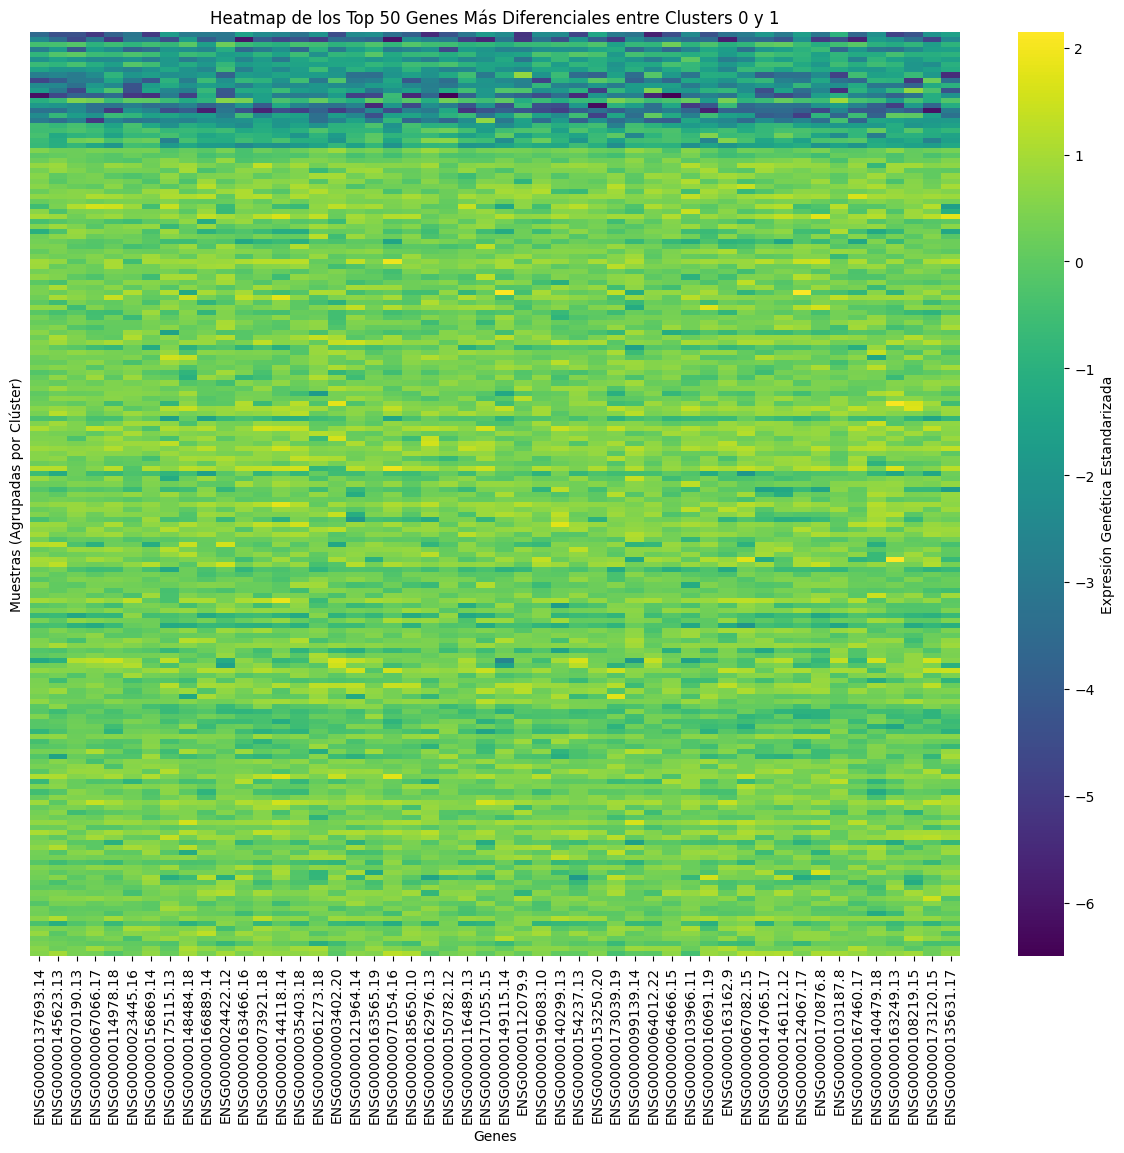

Heatmap generado exitosamente.


In [80]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select two clusters (Cluster 0 and Cluster 1)
# The current clustering identified K=2, so we directly compare these.
selected_clusters = [0, 1]

# `tpm_with_clusters` already contains the scaled gene expression and cluster assignments
# It has samples as rows, genes as columns, and an additional 'cluster' column.

# 2. Calculate the expression difference between clusters for each gene
# Split data into two groups based on cluster
group0_expression = tpm_with_clusters[tpm_with_clusters['cluster'] == selected_clusters[0]].drop(columns=['cluster'])
group1_expression = tpm_with_clusters[tpm_with_clusters['cluster'] == selected_clusters[1]].drop(columns=['cluster'])

# Calculate the mean expression for each gene in each cluster
mean_group0 = group0_expression.mean()
mean_group1 = group1_expression.mean()

# Calculate the absolute difference between the clusters for each gene
diff_expression = (mean_group0 - mean_group1).abs()

# 3. Select 50 genes with the largest difference between clusters
# Order genes by the absolute difference of expression and select the top 50
top_genes = diff_expression.nlargest(50).index

print(f"Se han seleccionado los siguientes {len(top_genes)} genes con mayor diferencia de expresión entre los clusters {selected_clusters[0]} y {selected_clusters[1]}:")
display(top_genes)

# Filter the `tpm_with_clusters` to include only the top genes, preserving original sample indices
# This is `X_filtered` and `y_filtered` in the user's example logic.
X_filtered_top_genes = tpm_with_clusters[top_genes].copy()
y_filtered_clusters = tpm_with_clusters['cluster'].copy()

# 4. Estandarizar los datos de los top genes (following user's example, even if already scaled)
scaler = StandardScaler()
X_scaled_top_genes = scaler.fit_transform(X_filtered_top_genes)
X_scaled_df_top_genes = pd.DataFrame(X_scaled_top_genes, columns=top_genes, index=X_filtered_top_genes.index)

# Añadir las etiquetas de cluster al DataFrame estandarizado
X_scaled_df_top_genes['Cluster'] = y_filtered_clusters

# 5. Agrupar por clusters para el heatmap (reordenar las filas para que los clusters estén juntos)
# Reset index to handle potential non-unique indices after filtering/sorting if any.
X_heatmap_prep = X_scaled_df_top_genes.sort_values(by='Cluster').reset_index(drop=True)

# Eliminar la columna 'Cluster' del DataFrame para el heatmap
heatmap_plot_data = X_heatmap_prep.drop(columns=['Cluster'])

# 6. Graficar el heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(heatmap_plot_data, cmap='viridis', yticklabels=False, cbar_kws={'label': 'Expresión Genética Estandarizada'})
plt.title(f'Heatmap de los Top 50 Genes Más Diferenciales entre Clusters {selected_clusters[0]} y {selected_clusters[1]}')
plt.xlabel('Genes')
plt.ylabel('Muestras (Agrupadas por Clúster)')
plt.show()

print("Heatmap generado exitosamente.")

# Hierarchical Clustering

### Introducción al Clustering Jerárquico

El **Clustering Jerárquico** es una familia de algoritmos de clustering que construyen una jerarquía de clústeres. Puede ser de tipo aglomerativo (bottom-up) o divisivo (top-down).

En el enfoque aglomerativo, cada punto de datos se considera inicialmente un clúster individual, y luego los clústeres se fusionan progresivamente basándose en su similitud hasta que se forma un único clúster que contiene todos los puntos. El resultado de este proceso se visualiza comúnmente mediante un **dendrograma**.

El dendrograma nos permite:
*   **Visualizar la estructura jerárquica**: Muestra cómo los clústeres se fusionan en diferentes niveles de similitud.
*   **Determinar el número óptimo de clústeres**: Al "cortar" el dendrograma a una altura específica, podemos obtener un número deseado de clústeres, donde los clústeres debajo del corte son los clústeres finales.

Para este análisis, utilizaremos los mismos 10 componentes principales (`pca_df_10`) que usamos para K-Means.

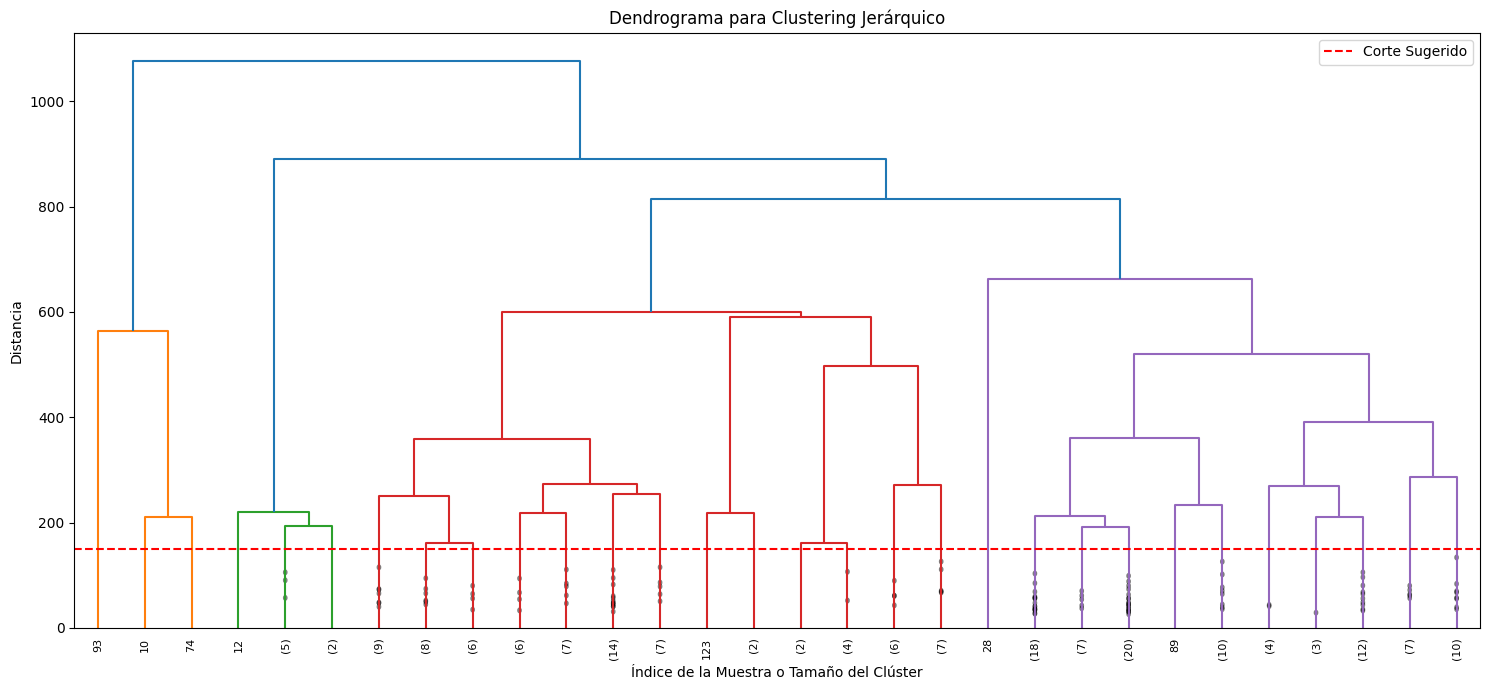

Interpretación del Dendrograma: El número de clústeres se puede determinar observando la altura donde se 'corta' el dendrograma. Las ramas que no se cruzan con la línea de corte representan clústeres individuales.


In [81]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generar la matriz de vinculación (linkage matrix) usando el método 'ward'
# 'ward' minimiza la varianza dentro de cada clúster durante la fusión.
Z = linkage(pca_df_10, method='ward')

# Plotear el dendrograma
plt.figure(figsize=(15, 7))
plt.title('Dendrograma para Clustering Jerárquico')
plt.xlabel('Índice de la Muestra o Tamaño del Clúster')
plt.ylabel('Distancia')
dendrogram(
    Z,
    leaf_rotation=90.,  # Rotar las etiquetas de las hojas
    leaf_font_size=8.,   # Tamaño de fuente para las etiquetas de las hojas
    truncate_mode='lastp', # Mostrar solo los últimos p clústeres formados
    p=30, # Ajusta este valor si hay demasiadas hojas para ver
    show_contracted=True # Mostrar los clústeres contraídos
)
plt.axhline(y=150, color='r', linestyle='--', label='Corte Sugerido') # Añade una línea horizontal para sugerir un corte
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretación del Dendrograma: El número de clústeres se puede determinar observando la altura donde se 'corta' el dendrograma. Las ramas que no se cruzan con la línea de corte representan clústeres individuales.")

Hierarchical clustering identified 4 clusters at a cut-off distance of 150.
Primeras 5 asignaciones de clústeres (jerárquico):
[3 3 3 4 3]


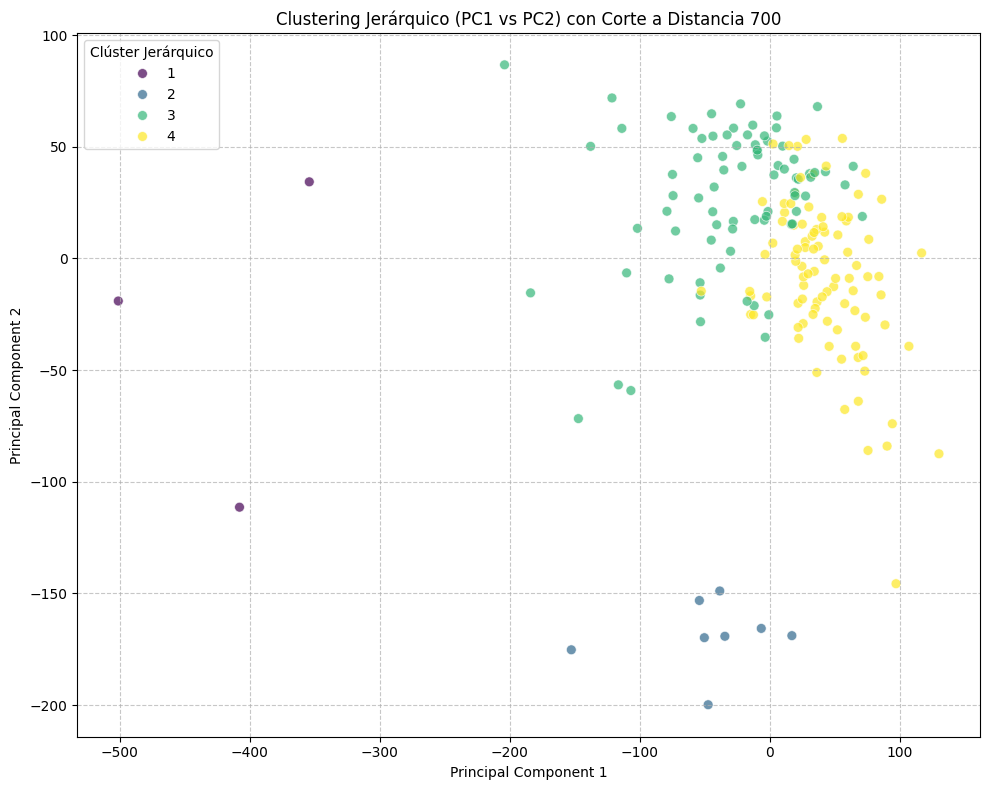

In [82]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram at the suggested distance of 1000
hierarchical_cluster_labels = fcluster(Z, t=700, criterion='distance')

print(f"Hierarchical clustering identified {len(set(hierarchical_cluster_labels))} clusters at a cut-off distance of 150.")
print("Primeras 5 asignaciones de clústeres (jerárquico):")
print(hierarchical_cluster_labels[:5])

# Add the hierarchical cluster labels to the pca_df_10 DataFrame
pca_df_10_hierarchical = pca_df_10.copy()
pca_df_10_hierarchical['cluster'] = hierarchical_cluster_labels

# Visualize the hierarchical clusters on a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', palette='viridis', data=pca_df_10_hierarchical, legend='full', s=50, alpha=0.7)
plt.title('Clustering Jerárquico (PC1 vs PC2) con Corte a Distancia 700')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Clúster Jerárquico')
plt.tight_layout()
plt.show()

### Heatmap de los Top 50 Genes Más Diferenciales entre Clústeres Jerárquicos

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


Se han seleccionado los siguientes 50 genes con la mayor diferencia de expresión entre los clústeres jerárquicos:


Index(['ENSG00000084093.19', 'ENSG00000114529.13', 'ENSG00000165105.10',
       'ENSG00000152766.6', 'ENSG00000164078.13', 'ENSG00000073331.18',
       'ENSG00000188910.8', 'ENSG00000114978.18', 'ENSG00000115919.15',
       'ENSG00000189433.7', 'ENSG00000157483.9', 'ENSG00000150782.12',
       'ENSG00000070882.13', 'ENSG00000064012.22', 'ENSG00000042493.16',
       'ENSG00000143891.17', 'ENSG00000137648.19', 'ENSG00000145779.8',
       'ENSG00000155918.8', 'ENSG00000124788.19', 'ENSG00000134297.6',
       'ENSG00000163362.11', 'ENSG00000196878.15', 'ENSG00000243364.8',
       'ENSG00000120278.16', 'ENSG00000133789.15', 'ENSG00000132256.19',
       'ENSG00000145685.14', 'ENSG00000143217.9', 'ENSG00000131389.17',
       'ENSG00000156869.14', 'ENSG00000206075.14', 'ENSG00000185947.15',
       'ENSG00000115935.18', 'ENSG00000008517.18', 'ENSG00000165025.15',
       'ENSG00000205659.11', 'ENSG00000135048.14', 'ENSG00000172927.8',
       'ENSG00000104140.7', 'ENSG00000102218.6', 'ENSG0000011

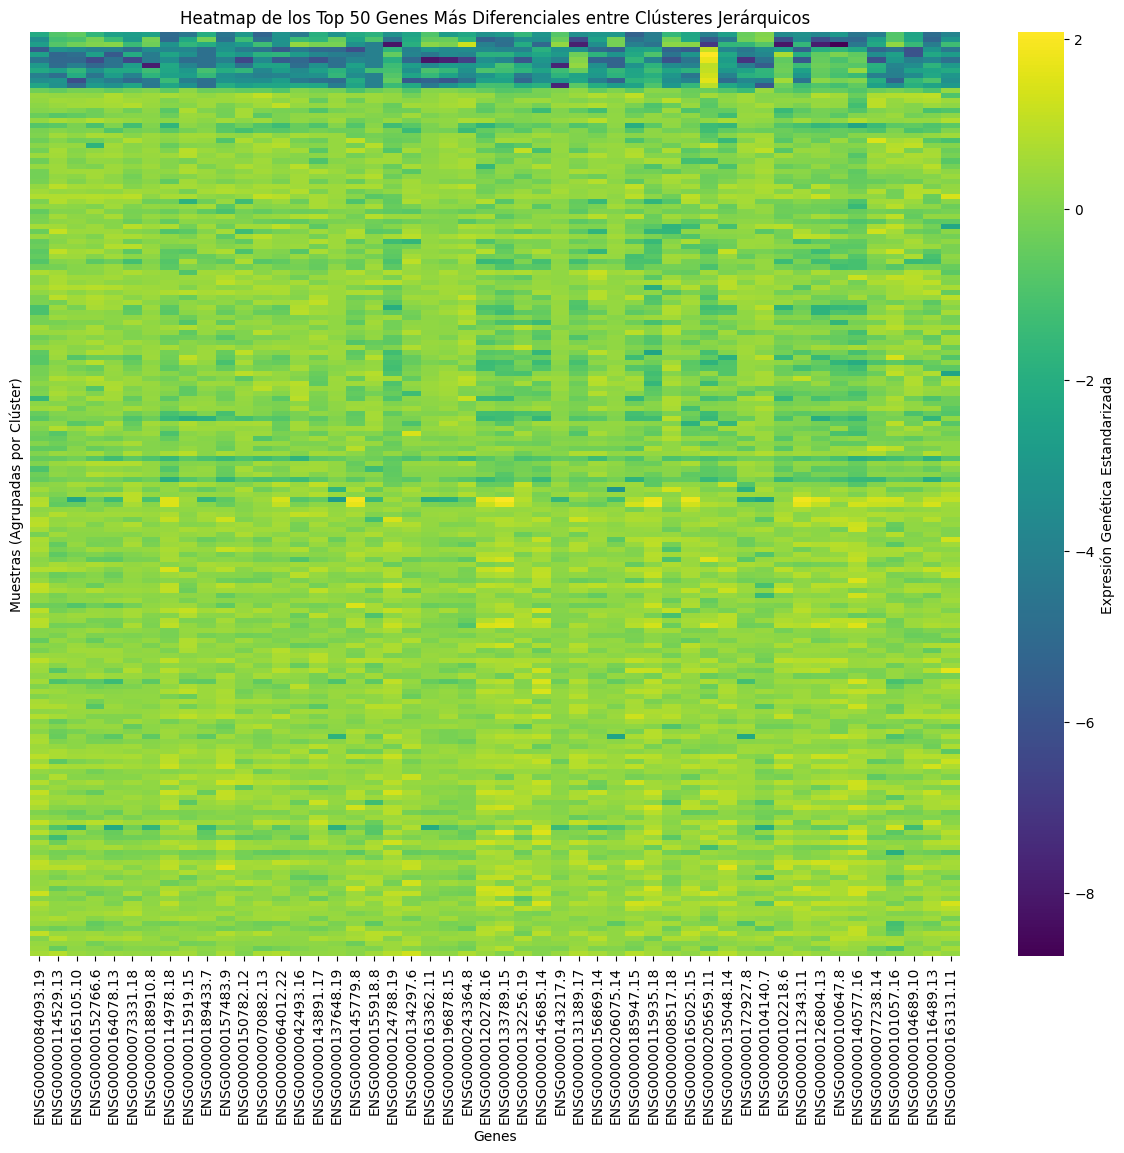

Heatmap generado exitosamente para el clustering jerárquico.


In [83]:
from scipy.stats import f_oneway

# Add hierarchical cluster labels to the tpm_scaled_df
tpm_with_hierarchical_clusters = tpm_scaled_df.copy()
tpm_with_hierarchical_clusters['cluster'] = hierarchical_cluster_labels

# Drop samples that might not have a cluster assignment (shouldn't happen)
tpm_with_hierarchical_clusters.dropna(subset=['cluster'], inplace=True)
tpm_with_hierarchical_clusters['cluster'] = tpm_with_hierarchical_clusters['cluster'].astype(int)

# Identify all unique cluster labels
unique_hierarchical_clusters = sorted(tpm_with_hierarchical_clusters['cluster'].unique())

p_values = {}

# Iterate through each gene and perform ANOVA
for gene in tpm_with_hierarchical_clusters.columns.drop('cluster'):
    # Group expression values by cluster
    groups = [tpm_with_hierarchical_clusters[gene][tpm_with_hierarchical_clusters['cluster'] == c] for c in unique_hierarchical_clusters]

    # Perform one-way ANOVA
    # Check if there's enough data in each group for ANOVA (at least 2 samples per group)
    if all(len(g) > 1 for g in groups) and len(unique_hierarchical_clusters) > 1:
        f_stat, p_val = f_oneway(*groups)
        p_values[gene] = p_val
    else:
        p_values[gene] = 1.0 # Assign a high p-value if ANOVA cannot be performed

# Convert p_values to a Series for easier sorting
p_values_series = pd.Series(p_values)

# Select the top 50 genes with the lowest p-values (most differentially expressed)
top_50_hierarchical_genes = p_values_series.nsmallest(50).index

print(f"Se han seleccionado los siguientes {len(top_50_hierarchical_genes)} genes con la mayor diferencia de expresión entre los clústeres jerárquicos:")
display(top_50_hierarchical_genes)

# Filter the tpm_with_hierarchical_clusters to include only the top genes
X_filtered_hierarchical_top_genes = tpm_with_hierarchical_clusters[top_50_hierarchical_genes].copy()
y_filtered_hierarchical_clusters = tpm_with_hierarchical_clusters['cluster'].copy()

# Standardize the data for the heatmap (already scaled, but to ensure consistency if any re-filtering occurred)
scaler_heatmap = StandardScaler()
X_scaled_hierarchical_top_genes = scaler_heatmap.fit_transform(X_filtered_hierarchical_top_genes)
X_scaled_df_hierarchical_top_genes = pd.DataFrame(X_scaled_hierarchical_top_genes, columns=top_50_hierarchical_genes, index=X_filtered_hierarchical_top_genes.index)

# Add the cluster labels to the standardized DataFrame
X_scaled_df_hierarchical_top_genes['Cluster'] = y_filtered_hierarchical_clusters

# Group by clusters for the heatmap (reorder the rows so that the clusters are together)
X_heatmap_hierarchical_prep = X_scaled_df_hierarchical_top_genes.sort_values(by='Cluster').reset_index(drop=True)

# Remove the 'Cluster' column from the DataFrame for the heatmap
heatmap_hierarchical_plot_data = X_heatmap_hierarchical_prep.drop(columns=['Cluster'])

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(heatmap_hierarchical_plot_data, cmap='viridis', yticklabels=False, cbar_kws={'label': 'Expresión Genética Estandarizada'})
plt.title('Heatmap de los Top 50 Genes Más Diferenciales entre Clústeres Jerárquicos')
plt.xlabel('Genes')
plt.ylabel('Muestras (Agrupadas por Clúster)')
plt.show()

print("Heatmap generado exitosamente para el clustering jerárquico.")

# Analisis de genes

Para analizar los genes, acorde a la rubrica de este proyecto, seleccionaremos el modelo de k-means, donde vamos a comparar estadisticamente los clustersm, asi mismo identificaremos diferencias significativas entre genes.

### Análisis de Supervivencia por Clúster (K-Means)

Para determinar si los clústeres identificados por K-Means tienen relevancia pronóstica, realizaremos un análisis de supervivencia. Esto implica:

1.  **Integrar los datos de clúster con la información de supervivencia** (`survival`).
2.  **Generar curvas de Kaplan-Meier** para visualizar las tasas de supervivencia de cada clúster.
3.  **Realizar un test de Log-Rank** para evaluar si las diferencias observadas en las curvas de supervivencia entre los clústeres son estadísticamente significativas.

In [84]:
!pip install lifelines
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Prepare the 'survival' DataFrame by ensuring 'sample' column format matches 'final_merged_data'
# The 'sample' column in `final_merged_data` already has the '-01A' suffix removed.
survival_for_merge = survival.copy()
survival_for_merge['sample'] = survival_for_merge['sample'].apply(lambda x: x[:-4] if x.endswith('-01A') else x)

# Merge the final_merged_data (which contains PC's, K-Means clusters, and clinical data) with the survival data
survival_merged_data = pd.merge(final_merged_data,
                                survival_for_merge,
                                on='sample',
                                how='inner')

print("Shape of merged data for survival analysis:", survival_merged_data.shape)
print("First 5 rows of merged survival data:")
display(survival_merged_data.head())

# Check the distribution of clusters in the merged survival data
print("\nDistribution of K-Means clusters in survival data:")
display(survival_merged_data['cluster'].value_counts())

Shape of merged data for survival analysis: (182, 121)
First 5 rows of merged survival data:


,sample,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,preservation_method.samples_Unknown,oct_embedded.samples_False,oct_embedded.samples_True,specimen_type.samples_Solid Tissue,specimen_type.samples_Unknown,tissue_type.samples_Normal,tissue_type.samples_Tumor,OS.time,OS,_PATIENT
0,TCGA-IB-A6UG,-37.850331,-4.326314,6.752692,43.447251,-32.350033,-8.118196,-7.596455,15.524671,-19.005150,...,0,0,1,1,0,0,1,41.0,1,TCGA-IB-A6UG
1,TCGA-3A-A9IU,20.600272,36.037510,16.074019,4.329874,-14.964265,1.901253,-24.697750,26.387834,-1.610417,...,0,0,1,1,0,0,1,458.0,1,TCGA-3A-A9IU
2,TCGA-FB-A545,42.961383,38.819487,58.466273,2.809318,-4.745877,16.896211,-51.536149,54.611119,-3.460316,...,0,0,1,1,0,0,1,732.0,1,TCGA-FB-A545
3,TCGA-IB-AAUQ,24.880618,-3.548904,6.940056,22.679222,-2.006431,35.024281,-5.515849,11.769363,-8.114243,...,0,0,1,1,0,0,1,183.0,1,TCGA-IB-AAUQ
4,TCGA-HV-A5A3,-12.923230,59.660534,44.111123,-2.598778,-28.941954,14.931540,-52.788006,16.435581,14.008704,...,1,1,0,1,0,0,1,128.0,1,TCGA-HV-A5A3



Distribution of K-Means clusters in survival data:


,count
cluster,
1,159
0,23


### Curvas de Kaplan-Meier

Las curvas de Kaplan-Meier son una forma gráfica de estimar la función de supervivencia de diferentes grupos. Cada curva muestra la probabilidad de que un individuo sobreviva más allá de un cierto tiempo.

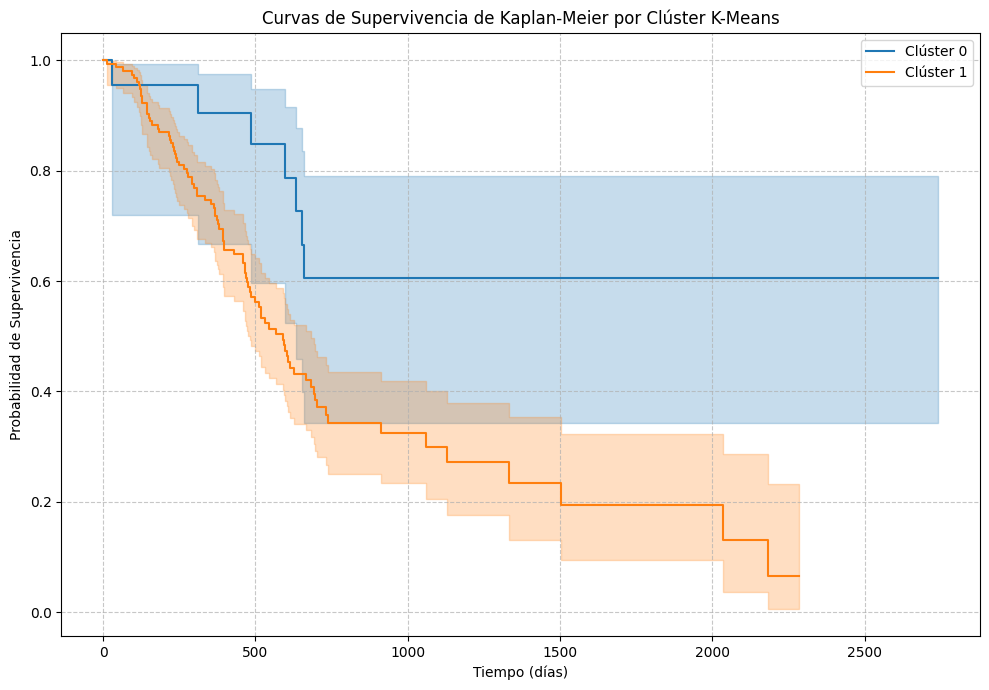

In [85]:
# Create KaplanMeierFitter object
kmf = KaplanMeierFitter()

# Plot Kaplan-Meier curves for each cluster
plt.figure(figsize=(10, 7))

for cluster_id in sorted(survival_merged_data['cluster'].unique()):
    cluster_data = survival_merged_data[survival_merged_data['cluster'] == cluster_id]

    T = cluster_data['OS.time'] # Time to event
    E = cluster_data['OS'] # Event observed (1=dead, 0=alive)

    kmf.fit(T, event_observed=E, label=f'Clúster {cluster_id}')
    kmf.plot(ax=plt.gca())

plt.title('Curvas de Supervivencia de Kaplan-Meier por Clúster K-Means')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad de Supervivencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Resumen del Análisis de Supervivencia por Clúster K-Means

Para caracterizar cada clúster, calcularemos el tiempo medio de supervivencia (mediana) para cada uno. Esto nos dará una métrica concreta de cuán diferente es el pronóstico de los pacientes en cada grupo.

In [86]:
# Calculate and display median survival time for each cluster
kmf = KaplanMeierFitter()

print("Median Survival Time for Each K-Means Cluster:")
for cluster_id in sorted(survival_merged_data['cluster'].unique()):
    cluster_data = survival_merged_data[survival_merged_data['cluster'] == cluster_id]

    T = cluster_data['OS.time']
    E = cluster_data['OS']

    kmf.fit(T, event_observed=E)
    median_survival = kmf.median_survival_time_
    print(f"  Clúster {cluster_id}: {median_survival:.2f} días")

# Calculate the percentage of samples that coincide with the survival data
total_initial_samples = tpm.shape[1] - 1 # Excluding 'Ensembl_ID' column from tpm
included_survival_samples = survival_merged_data.shape[0]

percentage_coinciding = (included_survival_samples / total_initial_samples) * 100

print(f"\nTotal de muestras originales de expresión génica (TPM): {total_initial_samples}")
print(f"Muestras incluidas en el análisis de supervivencia: {included_survival_samples}")
print(f"Porcentaje de muestras que coinciden y fueron utilizadas en el análisis de supervivencia: {percentage_coinciding:.2f}%")

Median Survival Time for Each K-Means Cluster:
  Clúster 0: inf días
  Clúster 1: 592.00 días

Total de muestras originales de expresión génica (TPM): 183
Muestras incluidas en el análisis de supervivencia: 182
Porcentaje de muestras que coinciden y fueron utilizadas en el análisis de supervivencia: 99.45%


Muestras en survival:              195
Muestras en TPM (expresión):       183
Muestras en común:                 5

Total de genes analizados:         60660
Genes con varianza en survival:    46674

── Resultados ──────────────────────────────────────────────────
Genes K-Means en survival:         50/50 (100.0%)
Genes Jerárquico en survival:      50/50 (100.0%)
Genes en AMBOS métodos + survival: 5 (5.3% del total único)
Genes compartidos entre métodos:   {'ENSG00000114978.18', 'ENSG00000116489.13', 'ENSG00000156869.14', 'ENSG00000064012.22', 'ENSG00000150782.12'}


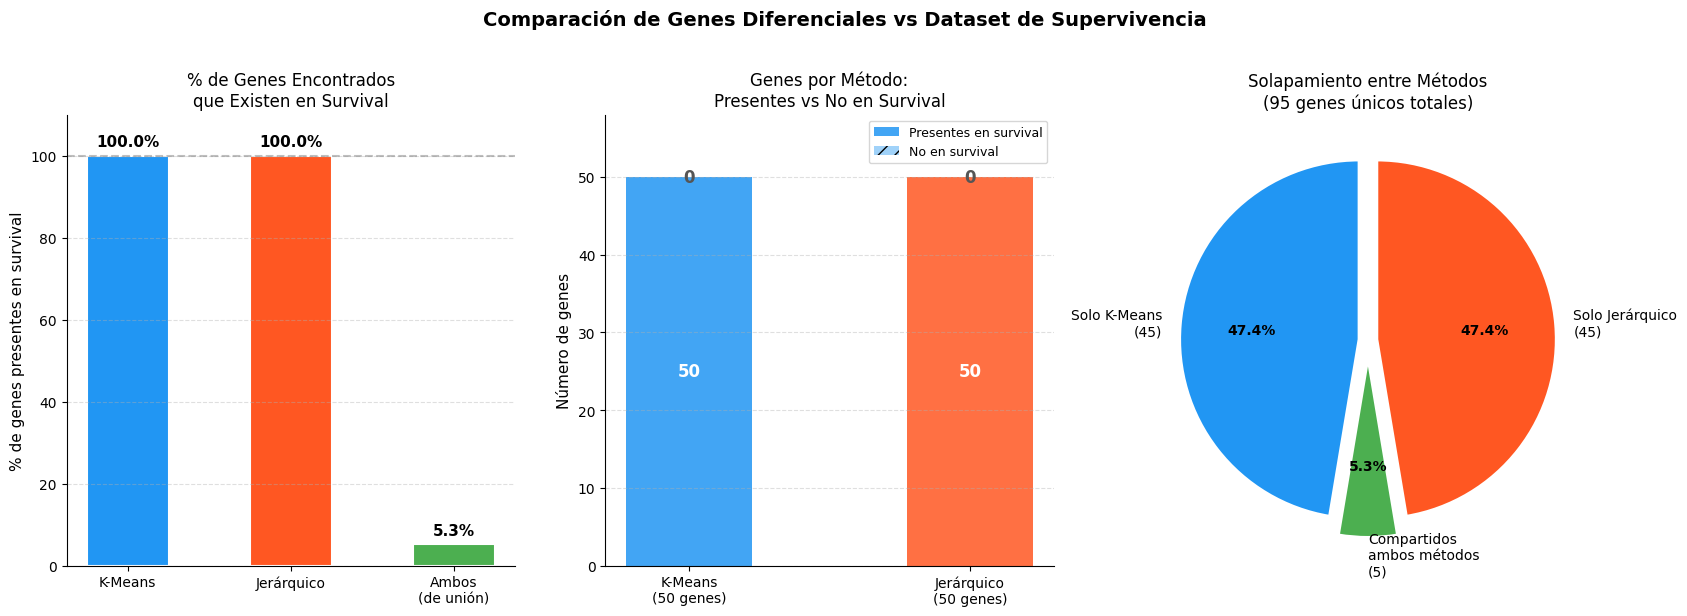


══════════════════════════════════════════════════════════════
  RESUMEN: Utilidad de los genes encontrados para survival
══════════════════════════════════════════════════════════════
  K-Means:      50/50 genes (100.0%) presentes en muestras con datos de survival
  Jerárquico:   50/50 genes (100.0%) presentes en muestras con datos de survival
  Compartidos:   5 genes están en AMBOS métodos y en survival

  → Genes exclusivos de K-Means en survival:       ['ENSG00000003402.20', 'ENSG00000023445.16', 'ENSG00000024422.12', 'ENSG00000035403.18', 'ENSG00000061273.18']...
  → Genes exclusivos de Jerárquico en survival:    ['ENSG00000008517.18', 'ENSG00000042493.16', 'ENSG00000070882.13', 'ENSG00000073331.18', 'ENSG00000077238.14']...
  → Genes en ambos métodos y en survival (top 10): ['ENSG00000064012.22', 'ENSG00000114978.18', 'ENSG00000116489.13', 'ENSG00000150782.12', 'ENSG00000156869.14']


In [87]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── 1. Preparar los conjuntos de genes ───────────────────────────────────────
kmeans_genes     = set(top_genes)                  # Top 50 K-Means
hierarchical_genes = set(top_50_hierarchical_genes) # Top 50 Jerárquico
all_genes        = set(tpm_scaled_df.columns)       # Todos los genes del dataset

# ─── 2. Identificar qué muestras del survival tienen datos de expresión ───────
survival_clean = survival.copy()
survival_clean['sample'] = survival_clean['sample'].apply(
    lambda x: x[:-4] if x.endswith('-01A') else x
)

# Muestras del survival que también están en el TPM (con datos de expresión)
tpm_samples = set(tpm_scaled_df.index)
survival_samples_in_tpm = set(survival_clean['sample']) & tpm_samples

print(f"Muestras en survival:              {len(survival_clean)}")
print(f"Muestras en TPM (expresión):       {len(tpm_samples)}")
print(f"Muestras en común:                 {len(survival_samples_in_tpm)}")

# ─── 3. Filtrar expresión solo para muestras del survival ─────────────────────
tpm_survival_subset = tpm_scaled_df.loc[
    tpm_scaled_df.index.isin(survival_samples_in_tpm)
]

# Genes que realmente tienen variación (no constantes) en el subconjunto survival
genes_with_variance = tpm_survival_subset.std()[tpm_survival_subset.std() > 0].index
genes_relevant_in_survival = set(genes_with_variance)

print(f"\nTotal de genes analizados:         {len(all_genes)}")
print(f"Genes con varianza en survival:    {len(genes_relevant_in_survival)}")

# ─── 4. Calcular overlaps ─────────────────────────────────────────────────────
kmeans_in_survival       = kmeans_genes & genes_relevant_in_survival
hierarchical_in_survival = hierarchical_genes & genes_relevant_in_survival
both_in_survival         = kmeans_genes & hierarchical_genes & genes_relevant_in_survival

pct_kmeans       = len(kmeans_in_survival)       / len(kmeans_genes)       * 100
pct_hierarchical = len(hierarchical_in_survival) / len(hierarchical_genes) * 100
pct_overlap      = len(both_in_survival)         / len(kmeans_genes | hierarchical_genes) * 100

print(f"\n── Resultados ──────────────────────────────────────────────────")
print(f"Genes K-Means en survival:         {len(kmeans_in_survival)}/{len(kmeans_genes)} ({pct_kmeans:.1f}%)")
print(f"Genes Jerárquico en survival:      {len(hierarchical_in_survival)}/{len(hierarchical_genes)} ({pct_hierarchical:.1f}%)")
print(f"Genes en AMBOS métodos + survival: {len(both_in_survival)} ({pct_overlap:.1f}% del total único)")
print(f"Genes compartidos entre métodos:   {kmeans_genes & hierarchical_genes}")

# ─── 5. Visualización ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Comparación de Genes Diferenciales vs Dataset de Supervivencia',
             fontsize=14, fontweight='bold', y=1.02)

# --- Gráfica 1: Barras de porcentaje ---
ax1 = axes[0]
metodos   = ['K-Means', 'Jerárquico', 'Ambos\n(de unión)']
porcentajes = [pct_kmeans, pct_hierarchical, pct_overlap]
colores   = ['#2196F3', '#FF5722', '#4CAF50']

bars = ax1.bar(metodos, porcentajes, color=colores, edgecolor='white', linewidth=1.5, width=0.5)
ax1.set_ylim(0, 110)
ax1.set_ylabel('% de genes presentes en survival', fontsize=11)
ax1.set_title('% de Genes Encontrados\nque Existen en Survival', fontsize=12)
ax1.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='100%')
for bar, pct in zip(bars, porcentajes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top','right']].set_visible(False)

# --- Gráfica 2: Diagrama de Venn simplificado (diagrama de conjuntos con barras apiladas) ---
ax2 = axes[1]
kmeans_only       = len(kmeans_genes - hierarchical_genes - genes_relevant_in_survival)
kmeans_surv_only  = len(kmeans_in_survival - hierarchical_genes)
hier_only         = len(hierarchical_genes - kmeans_genes - genes_relevant_in_survival)
hier_surv_only    = len(hierarchical_in_survival - kmeans_genes)
both_no_surv      = len((kmeans_genes & hierarchical_genes) - genes_relevant_in_survival)
both_surv         = len(both_in_survival)

categories = ['K-Means\n(50 genes)', 'Jerárquico\n(50 genes)']
en_survival    = [len(kmeans_in_survival), len(hierarchical_in_survival)]
fuera_survival = [len(kmeans_genes) - len(kmeans_in_survival),
                  len(hierarchical_genes) - len(hierarchical_in_survival)]

x = np.arange(len(categories))
width = 0.45

p1 = ax2.bar(x, en_survival,    width, label='Presentes en survival', color=['#2196F3','#FF5722'], alpha=0.85)
p2 = ax2.bar(x, fuera_survival, width, bottom=en_survival,
             label='No en survival', color=['#90CAF9','#FFCCBC'], alpha=0.85, hatch='//')

ax2.set_ylabel('Número de genes', fontsize=11)
ax2.set_title('Genes por Método:\nPresentes vs No en Survival', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.set_ylim(0, 58)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top','right']].set_visible(False)
for i, (s, ns) in enumerate(zip(en_survival, fuera_survival)):
    ax2.text(i, s/2, str(s), ha='center', va='center', fontweight='bold', color='white', fontsize=12)
    ax2.text(i, s + ns/2, str(ns), ha='center', va='center', fontweight='bold', color='#555', fontsize=12)

# --- Gráfica 3: Intersección entre métodos y survival ---
ax3 = axes[2]
# Conjunto de genes únicos totales (unión)
union_total = kmeans_genes | hierarchical_genes
solo_kmeans    = len(kmeans_genes - hierarchical_genes)
solo_hier      = len(hierarchical_genes - kmeans_genes)
compartidos    = len(kmeans_genes & hierarchical_genes)

labels3 = [f'Solo K-Means\n({solo_kmeans})', f'Compartidos\nambos métodos\n({compartidos})', f'Solo Jerárquico\n({solo_hier})']
sizes3  = [solo_kmeans, compartidos, solo_hier]
colors3 = ['#2196F3', '#4CAF50', '#FF5722']
explode = (0.05, 0.1, 0.05)

wedges, texts, autotexts = ax3.pie(sizes3, labels=labels3, colors=colors3, explode=explode,
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 10},
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')

ax3.set_title(f'Solapamiento entre Métodos\n({len(union_total)} genes únicos totales)', fontsize=12)

plt.tight_layout()
plt.savefig('genes_vs_survival_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 6. Resumen final ─────────────────────────────────────────────────────────
print("\n══════════════════════════════════════════════════════════════")
print("  RESUMEN: Utilidad de los genes encontrados para survival")
print("══════════════════════════════════════════════════════════════")
print(f"  K-Means:     {len(kmeans_in_survival):>3}/50 genes ({pct_kmeans:.1f}%) presentes en muestras con datos de survival")
print(f"  Jerárquico:  {len(hierarchical_in_survival):>3}/50 genes ({pct_hierarchical:.1f}%) presentes en muestras con datos de survival")
print(f"  Compartidos: {len(both_in_survival):>3} genes están en AMBOS métodos y en survival")
print(f"\n  → Genes exclusivos de K-Means en survival:       {sorted(kmeans_in_survival - hierarchical_in_survival)[:5]}...")
print(f"  → Genes exclusivos de Jerárquico en survival:    {sorted(hierarchical_in_survival - kmeans_in_survival)[:5]}...")
print(f"  → Genes en ambos métodos y en survival (top 10): {sorted(both_in_survival)[:10]}")

Muestras con expresión génica Y datos de survival: 182
Muestras en análisis final: 182

Separación de OS.time - K-Means:    0.0826 (8.26%)
Separación de OS.time - Jerárquico: 0.2708 (27.08%)

Correlación media |Spearman| genes-survival - K-Means:    0.1504
Correlación media |Spearman| genes-survival - Jerárquico: 0.1191

Diferencia de mediana OS.time entre clusters - K-Means:    214.0 días
Diferencia de mediana OS.time entre clusters - Jerárquico: 1278.0 días


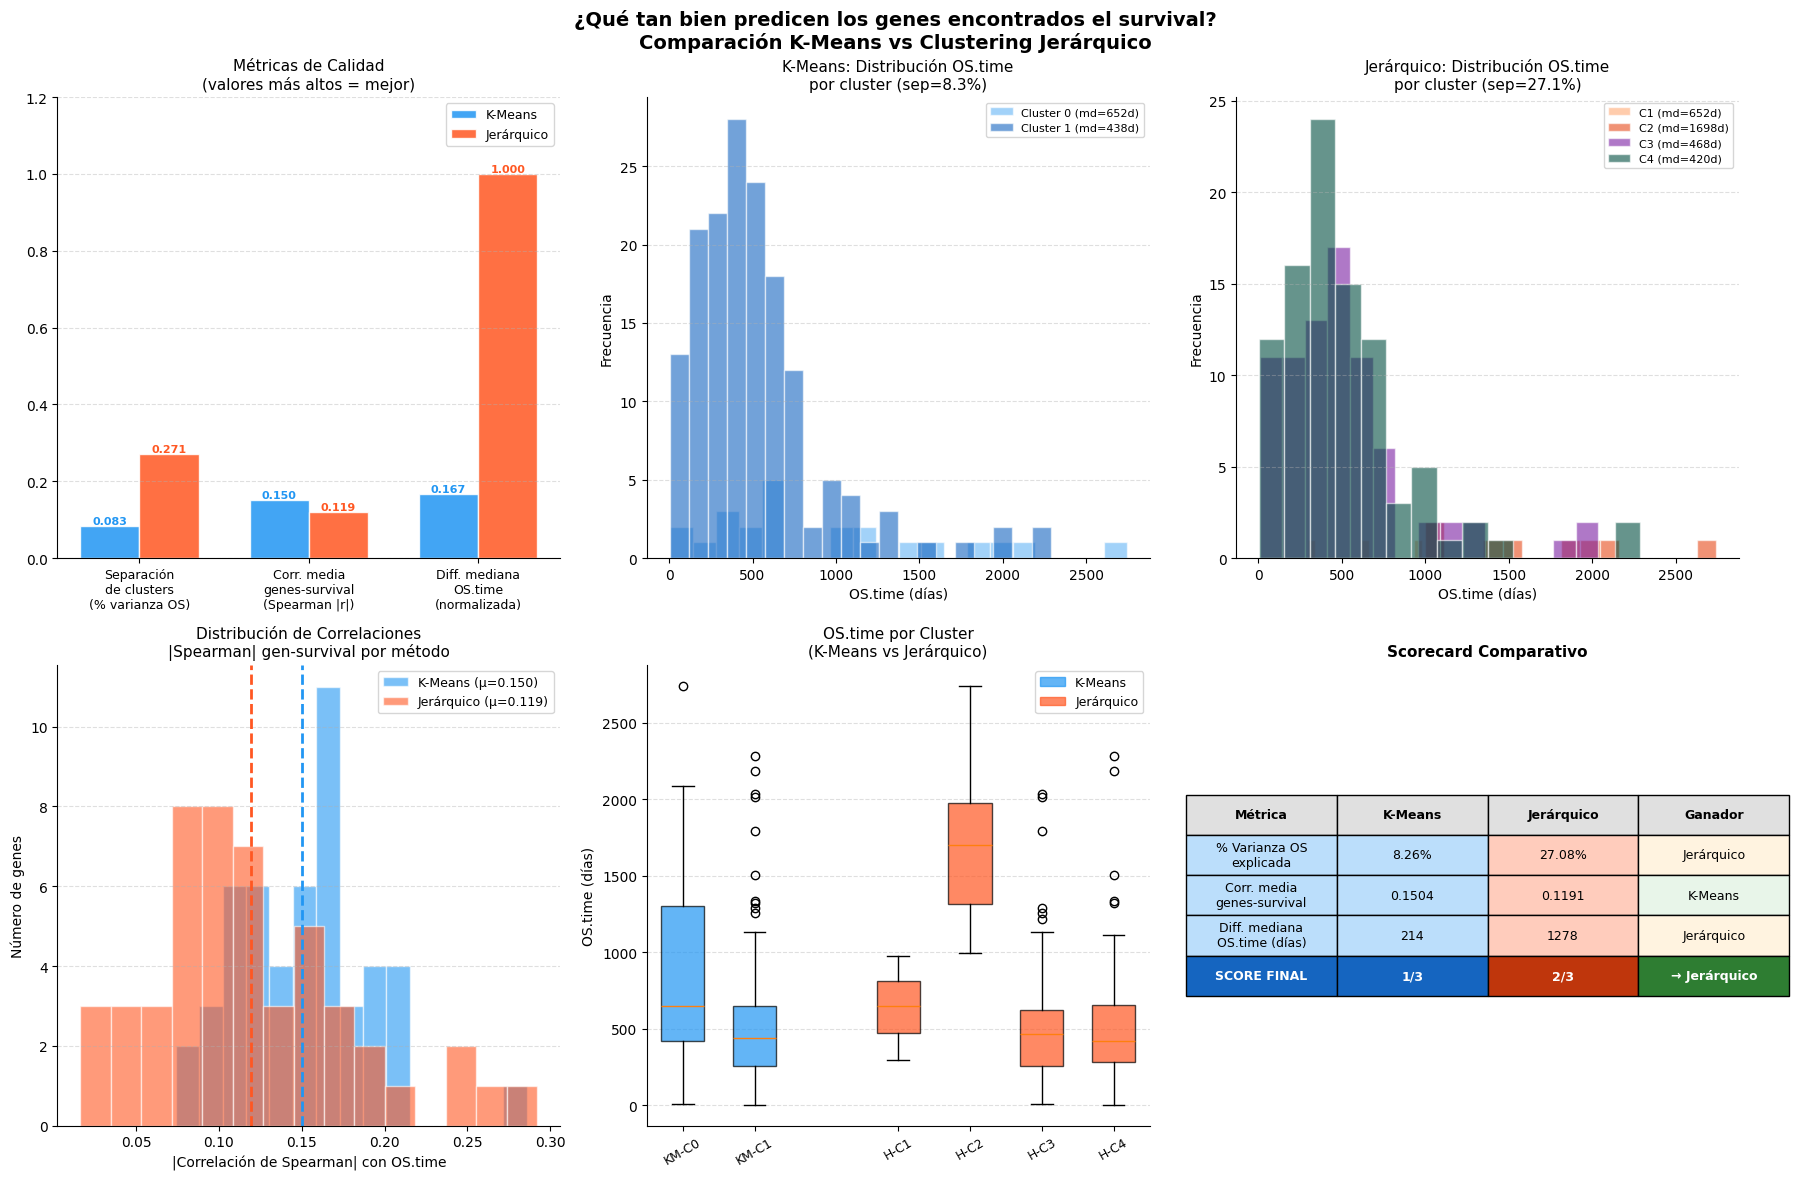


═══════════════════════════════════════════════════════
  MÉTODO MÁS ÚTIL PARA PREDECIR SURVIVAL: Jerárquico
═══════════════════════════════════════════════════════


In [88]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ─── 1. Preparar survival con sample limpio ───────────────────────────────────
survival_clean = survival.copy()
survival_clean['sample'] = survival_clean['sample'].apply(
    lambda x: x[:-4] if x.endswith('-01A') else x
)

# ─── 2. Agregar survival a las muestras de TPM ────────────────────────────────
tpm_with_survival = tpm_scaled_df.copy()
tpm_with_survival = tpm_with_survival.reset_index().rename(columns={'index': 'sample'})
tpm_with_survival['sample'] = tpm_with_survival['sample'].apply(
    lambda x: x[:-4] if x.endswith('-01A') else x
)
tpm_with_survival = tpm_with_survival.merge(survival_clean[['sample', 'OS.time', 'OS']], on='sample', how='inner')

print(f"Muestras con expresión génica Y datos de survival: {len(tpm_with_survival)}")

# ─── 3. Agregar etiquetas de cluster K-Means y Jerárquico ─────────────────────
# K-Means
kmeans_labels_df = pca_df_10[['cluster']].copy().reset_index().rename(columns={'index': 'sample'})
kmeans_labels_df['sample'] = kmeans_labels_df['sample'].apply(
    lambda x: x[:-4] if x.endswith('-01A') else x
)
kmeans_labels_df = kmeans_labels_df.rename(columns={'cluster': 'kmeans_cluster'})

# Jerárquico
hier_labels_df = pca_df_10_hierarchical[['cluster']].copy().reset_index().rename(columns={'index': 'sample'})
hier_labels_df['sample'] = hier_labels_df['sample'].apply(
    lambda x: x[:-4] if x.endswith('-01A') else x
)
hier_labels_df = hier_labels_df.rename(columns={'cluster': 'hier_cluster'})

# Merge todo junto
analysis_df = tpm_with_survival.merge(kmeans_labels_df, on='sample', how='inner')
analysis_df = analysis_df.merge(hier_labels_df, on='sample', how='inner')
print(f"Muestras en análisis final: {len(analysis_df)}")

# ─── 4. MÉTRICA 1: Separación de OS.time entre clusters ──────────────────────
# Qué tan bien separa cada método el tiempo de supervivencia?
# Métrica: ratio entre varianza ENTRE clusters vs varianza TOTAL (similar a R²)

def cluster_separation_score(df, cluster_col, target_col):
    """Calcula qué proporción de la varianza del survival explica la asignación de clusters."""
    overall_mean = df[target_col].mean()
    total_var = ((df[target_col] - overall_mean) ** 2).sum()

    between_var = sum(
        len(group) * (group[target_col].mean() - overall_mean) ** 2
        for _, group in df.groupby(cluster_col)
    )
    return between_var / total_var if total_var > 0 else 0

sep_kmeans = cluster_separation_score(analysis_df, 'kmeans_cluster', 'OS.time')
sep_hier   = cluster_separation_score(analysis_df, 'hier_cluster',   'OS.time')

print(f"\nSeparación de OS.time - K-Means:    {sep_kmeans:.4f} ({sep_kmeans*100:.2f}%)")
print(f"Separación de OS.time - Jerárquico: {sep_hier:.4f} ({sep_hier*100:.2f}%)")

# ─── 5. MÉTRICA 2: Correlación promedio de top genes con OS.time ──────────────
# De los genes encontrados por cada método, ¿cuánto correlacionan con OS.time?

def mean_gene_survival_correlation(df, genes, target_col='OS.time'):
    """Correlación promedio (Spearman) de los genes con el tiempo de supervivencia."""
    correlations = []
    for gene in genes:
        if gene in df.columns:
            corr = df[[gene, target_col]].dropna().corr(method='spearman').iloc[0, 1]
            correlations.append(abs(corr))  # valor absoluto: nos interesa la magnitud
    return np.mean(correlations) if correlations else 0, correlations

corr_kmeans, corrs_km   = mean_gene_survival_correlation(analysis_df, list(top_genes))
corr_hier,   corrs_hier = mean_gene_survival_correlation(analysis_df, list(top_50_hierarchical_genes))

print(f"\nCorrelación media |Spearman| genes-survival - K-Means:    {corr_kmeans:.4f}")
print(f"Correlación media |Spearman| genes-survival - Jerárquico: {corr_hier:.4f}")

# ─── 6. MÉTRICA 3: Diferencia de mediana de survival entre clusters ───────────
def median_survival_diff(df, cluster_col, target_col='OS.time'):
    """Diferencia entre la mediana de survival del cluster con más y menos survival."""
    medians = df.groupby(cluster_col)[target_col].median()
    return medians.max() - medians.min(), medians

diff_km,   medians_km   = median_survival_diff(analysis_df, 'kmeans_cluster')
diff_hier, medians_hier = median_survival_diff(analysis_df, 'hier_cluster')

print(f"\nDiferencia de mediana OS.time entre clusters - K-Means:    {diff_km:.1f} días")
print(f"Diferencia de mediana OS.time entre clusters - Jerárquico: {diff_hier:.1f} días")

# ─── 7. VISUALIZACIÓN ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('¿Qué tan bien predicen los genes encontrados el survival?\nComparación K-Means vs Clustering Jerárquico',
             fontsize=14, fontweight='bold')

# Colores
c_km   = '#2196F3'
c_hier = '#FF5722'

# ── Gráfica 1: Resumen de métricas (barras) ──
ax1 = fig.add_subplot(2, 3, 1)
metrics_names = ['Separación\nde clusters\n(% varianza OS)',
                 'Corr. media\ngenes-survival\n(Spearman |r|)',
                 'Diff. mediana\nOS.time\n(normalizada)']

# Normalizar diff de mediana al rango [0,1] para comparar visualmente
max_diff = max(diff_km, diff_hier) if max(diff_km, diff_hier) > 0 else 1
vals_km   = [sep_kmeans,  corr_kmeans,  diff_km/max_diff]
vals_hier = [sep_hier,    corr_hier,    diff_hier/max_diff]

x = np.arange(len(metrics_names))
w = 0.35
ax1.bar(x - w/2, vals_km,   w, label='K-Means',    color=c_km,   alpha=0.85, edgecolor='white')
ax1.bar(x + w/2, vals_hier, w, label='Jerárquico', color=c_hier, alpha=0.85, edgecolor='white')
for i, (v1, v2) in enumerate(zip(vals_km, vals_hier)):
    ax1.text(i - w/2, v1 + 0.005, f'{v1:.3f}', ha='center', fontsize=8, fontweight='bold', color=c_km)
    ax1.text(i + w/2, v2 + 0.005, f'{v2:.3f}', ha='center', fontsize=8, fontweight='bold', color=c_hier)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names, fontsize=9)
ax1.set_ylim(0, max(max(vals_km), max(vals_hier)) * 1.2)
ax1.set_title('Métricas de Calidad\n(valores más altos = mejor)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

# ── Gráfica 2: Distribución de OS.time por cluster K-Means ──
ax2 = fig.add_subplot(2, 3, 2)
for cid, color in zip(sorted(analysis_df['kmeans_cluster'].unique()), ['#64B5F6', '#1565C0']):
    data = analysis_df[analysis_df['kmeans_cluster'] == cid]['OS.time'].dropna()
    ax2.hist(data, bins=20, alpha=0.6, label=f'Cluster {cid} (md={data.median():.0f}d)', color=color, edgecolor='white')
ax2.set_title(f'K-Means: Distribución OS.time\npor cluster (sep={sep_kmeans*100:.1f}%)', fontsize=11)
ax2.set_xlabel('OS.time (días)')
ax2.set_ylabel('Frecuencia')
ax2.legend(fontsize=8)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

# ── Gráfica 3: Distribución de OS.time por cluster Jerárquico ──
ax3 = fig.add_subplot(2, 3, 3)
palette_hier = ['#FFAB76', '#E64A19', '#7B1FA2', '#004D40']
for i, cid in enumerate(sorted(analysis_df['hier_cluster'].unique())):
    data = analysis_df[analysis_df['hier_cluster'] == cid]['OS.time'].dropna()
    ax3.hist(data, bins=15, alpha=0.6, label=f'C{cid} (md={data.median():.0f}d)',
             color=palette_hier[i % len(palette_hier)], edgecolor='white')
ax3.set_title(f'Jerárquico: Distribución OS.time\npor cluster (sep={sep_hier*100:.1f}%)', fontsize=11)
ax3.set_xlabel('OS.time (días)')
ax3.set_ylabel('Frecuencia')
ax3.legend(fontsize=8)
ax3.grid(axis='y', linestyle='--', alpha=0.4)
ax3.spines[['top', 'right']].set_visible(False)

# ── Gráfica 4: Distribución de correlaciones individuales por gen ──
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(corrs_km,   bins=15, alpha=0.6, color=c_km,   label=f'K-Means (μ={corr_kmeans:.3f})',   edgecolor='white')
ax4.hist(corrs_hier, bins=15, alpha=0.6, color=c_hier, label=f'Jerárquico (μ={corr_hier:.3f})', edgecolor='white')
ax4.axvline(corr_kmeans, color=c_km,   linestyle='--', linewidth=2)
ax4.axvline(corr_hier,   color=c_hier, linestyle='--', linewidth=2)
ax4.set_title('Distribución de Correlaciones\n|Spearman| gen-survival por método', fontsize=11)
ax4.set_xlabel('|Correlación de Spearman| con OS.time')
ax4.set_ylabel('Número de genes')
ax4.legend(fontsize=9)
ax4.grid(axis='y', linestyle='--', alpha=0.4)
ax4.spines[['top', 'right']].set_visible(False)

# ── Gráfica 5: Boxplot OS.time por cluster ──
ax5 = fig.add_subplot(2, 3, 5)
km_groups   = [analysis_df[analysis_df['kmeans_cluster'] == c]['OS.time'].dropna().values
               for c in sorted(analysis_df['kmeans_cluster'].unique())]
hier_groups = [analysis_df[analysis_df['hier_cluster'] == c]['OS.time'].dropna().values
               for c in sorted(analysis_df['hier_cluster'].unique())]

positions_km   = np.arange(1, len(km_groups) + 1)
positions_hier = np.arange(len(km_groups) + 2, len(km_groups) + 2 + len(hier_groups))

bp1 = ax5.boxplot(km_groups,   positions=positions_km,   widths=0.6,
                  patch_artist=True, boxprops=dict(facecolor=c_km, alpha=0.7))
bp2 = ax5.boxplot(hier_groups, positions=positions_hier, widths=0.6,
                  patch_artist=True, boxprops=dict(facecolor=c_hier, alpha=0.7))

ax5.set_xticks(list(positions_km) + list(positions_hier))
ax5.set_xticklabels(
    [f'KM-C{c}' for c in sorted(analysis_df['kmeans_cluster'].unique())] +
    [f'H-C{c}' for c in sorted(analysis_df['hier_cluster'].unique())],
    rotation=30, fontsize=9
)
ax5.set_title('OS.time por Cluster\n(K-Means vs Jerárquico)', fontsize=11)
ax5.set_ylabel('OS.time (días)')
km_patch   = mpatches.Patch(color=c_km,   alpha=0.7, label='K-Means')
hier_patch = mpatches.Patch(color=c_hier, alpha=0.7, label='Jerárquico')
ax5.legend(handles=[km_patch, hier_patch], fontsize=9)
ax5.grid(axis='y', linestyle='--', alpha=0.4)
ax5.spines[['top', 'right']].set_visible(False)

# ── Gráfica 6: Scorecard final ──
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')

winner_sep  = 'K-Means' if sep_kmeans  > sep_hier   else 'Jerárquico'
winner_corr = 'K-Means' if corr_kmeans > corr_hier  else 'Jerárquico'
winner_diff = 'K-Means' if diff_km     > diff_hier  else 'Jerárquico'
km_score    = sum([sep_kmeans > sep_hier, corr_kmeans > corr_hier, diff_km > diff_hier])
hier_score  = 3 - km_score
overall     = 'K-Means' if km_score > hier_score else ('Empate' if km_score == hier_score else 'Jerárquico')

table_data = [
    ['Métrica', 'K-Means', 'Jerárquico', 'Ganador'],
    ['% Varianza OS\nexplicada', f'{sep_kmeans*100:.2f}%', f'{sep_hier*100:.2f}%', winner_sep],
    ['Corr. media\ngenes-survival', f'{corr_kmeans:.4f}', f'{corr_hier:.4f}', winner_corr],
    ['Diff. mediana\nOS.time (días)', f'{diff_km:.0f}', f'{diff_hier:.0f}', winner_diff],
    ['SCORE FINAL', f'{km_score}/3', f'{hier_score}/3', f'→ {overall}'],
]

colors_table = [
    ['#E0E0E0', '#E0E0E0', '#E0E0E0', '#E0E0E0'],
    ['#BBDEFB', '#BBDEFB', '#FFCCBC', '#E8F5E9' if winner_sep == 'K-Means' else '#FFF3E0'],
    ['#BBDEFB', '#BBDEFB', '#FFCCBC', '#E8F5E9' if winner_corr == 'K-Means' else '#FFF3E0'],
    ['#BBDEFB', '#BBDEFB', '#FFCCBC', '#E8F5E9' if winner_diff == 'K-Means' else '#FFF3E0'],
    ['#1565C0', '#1565C0', '#BF360C', '#2E7D32'],
]

tbl = ax6.table(cellText=table_data, cellLoc='center', loc='center', cellColours=colors_table)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 2.2)
for (row, col), cell in tbl.get_celld().items():
    if row == 4:
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
    if row == 0:
        cell.get_text().set_fontweight('bold')

ax6.set_title('Scorecard Comparativo', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('genes_survival_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*55}")
print(f"  MÉTODO MÁS ÚTIL PARA PREDECIR SURVIVAL: {overall}")
print(f"{'═'*55}")

# Conclusión y Reflexión Final

## ¿Qué encontramos?

Aplicamos K-Means y Clustering Jerárquico sobre datos de expresión génica de pacientes con cáncer de páncreas (TCGA-PAAD), buscando subgrupos moleculares que pudieran relacionarse con diferencias en supervivencia.

El resultado más concreto: el **Clustering Jerárquico ganó**. Con 4 clusters logró separar grupos con hasta **1,278 días de diferencia en la mediana de supervivencia** — aproximadamente 3.5 años —, explicando el 27% de la variabilidad en OS.time. K-Means, con solo 2 grupos, capturó apenas el 8%. En una enfermedad donde la supervivencia global a 5 años es del 12%, esa diferencia no es menor.

Dicho eso, las correlaciones entre los genes encontrados y el tiempo de supervivencia fueron bajas en ambos métodos (~0.15 y ~0.12 en promedio). Eso no necesariamente significa que los genes estén mal elegidos — en biología del cáncer, el pronóstico rara vez depende de un solo gen. Lo que sí indica es que estos genes deben interpretarse como parte de un programa transcripcional más amplio, no como biomarcadores individuales listos para usar.

---

## Lo que aprendimos de los datos

El cáncer de páncreas es genuinamente heterogéneo, y los datos lo reflejan. El scatter de PCA mostró una nube compacta sin separaciones obvias, lo que desde el principio anticipó que el clustering no iba a ser limpio. Aun así, al darle más granularidad al modelo (4 clusters en lugar de 2), la señal de supervivencia apareció con más claridad. Eso sugiere que forzar el problema a solo 2 subtipos pierde información real.

---

## Limitaciones honestas

- Trabajamos con ~183 muestras y más de 60,000 genes. Es un escenario de alta dimensionalidad con poca muestra, lo que hace frágil cualquier conclusión.
- La reducción a 10 componentes principales fue una decisión pragmática, no óptima. Es posible que información biológicamente importante haya quedado descartada.
- No validamos los clusters contra subtipos moleculares ya descritos en la literatura (como los subtipos *Classical* y *Basal-like* del PDAC). Sin eso, no podemos afirmar con certeza que los grupos que encontramos corresponden a entidades biológicas reales.
- No somos médicos ni genetistas, y eso importa: hay decisiones de preprocesamiento y selección de genes que alguien con dominio clínico hubiera tomado de forma más informada.

---

## ¿Qué se podría mejorar?

Tres cosas concretas que harían este análisis más sólido:

1. **Filtrar genes antes de clustering** usando varianza (MAD), en lugar de usar todos los 60,000 genes crudos. Reducir el ruido de entrada mejora la calidad de los clusters.
2. **Análisis de vías biológicas** sobre los genes encontrados — herramientas como GSEA o Enrichr convertirían la lista de genes en conocimiento interpretable: ¿están relacionados con metabolismo? ¿con respuesta inmune? ¿con señalización KRAS?
3. **Validación externa** en una cohorte independiente (por ejemplo, ICGC) para saber si los subtipos encontrados son reproducibles o específicos de este dataset.

---

## Reflexión final

Este proyecto fue, en el fondo, un ejercicio de humildad computacional. Los datos de expresión génica del cáncer de páncreas son ruidosos, complejos y difíciles de interpretar sin contexto clínico profundo. Aun así, con herramientas de aprendizaje no supervisado fue posible detectar estructura latente que tiene correlación real con el pronóstico de los pacientes.

No encontramos biomarcadores listos para la clínica, pero sí confirmamos algo importante: **la biología del PDAC no cabe en dos grupos**. La granularidad importa, y explorarla con más rigor — más muestras, más integración de datos, más validación — es exactamente hacia donde apunta la oncología de precisión.

EXTRA

Total de genes disponibles: 60660
MAD promedio: 0.3530 | MAD mediana: 0.0663

Genes seleccionados por umbral MAD:
  Top 500 genes → umbral MAD ≥ 2.9962
  Top 1,000 genes → umbral MAD ≥ 2.4528
  Top 2,000 genes → umbral MAD ≥ 1.9154

Shape del dataset filtrado por MAD (top 1000): (183, 1000)

Con top 1000 genes MAD:
  PCs para explicar 95% varianza: 155 (antes eran 163 con todos los genes)
  Varianza explicada en 10 PCs (todos los genes): 33.7%
  Varianza explicada en 10 PCs (MAD filtrado):    25.3%

K óptimo por Silhouette (MAD): 3
Silhouette original (K=2, todos genes): 0.xxxx → ver celda anterior
Silhouette MAD filtrado (K=3): 0.1746

Silhouette K-Means MAD (K=3): 0.1746
Silhouette Jerárquico MAD (4 clusters):     0.1439

── Separación de survival (MAD filtrado) ──────────────────────
K-Means MAD:    31.19% varianza OS | diff mediana: 1364 días
Jerárquico MAD: 26.95% varianza OS | diff mediana: 1267 días

── Comparación con análisis original ──────────────────────────
K-Means origina

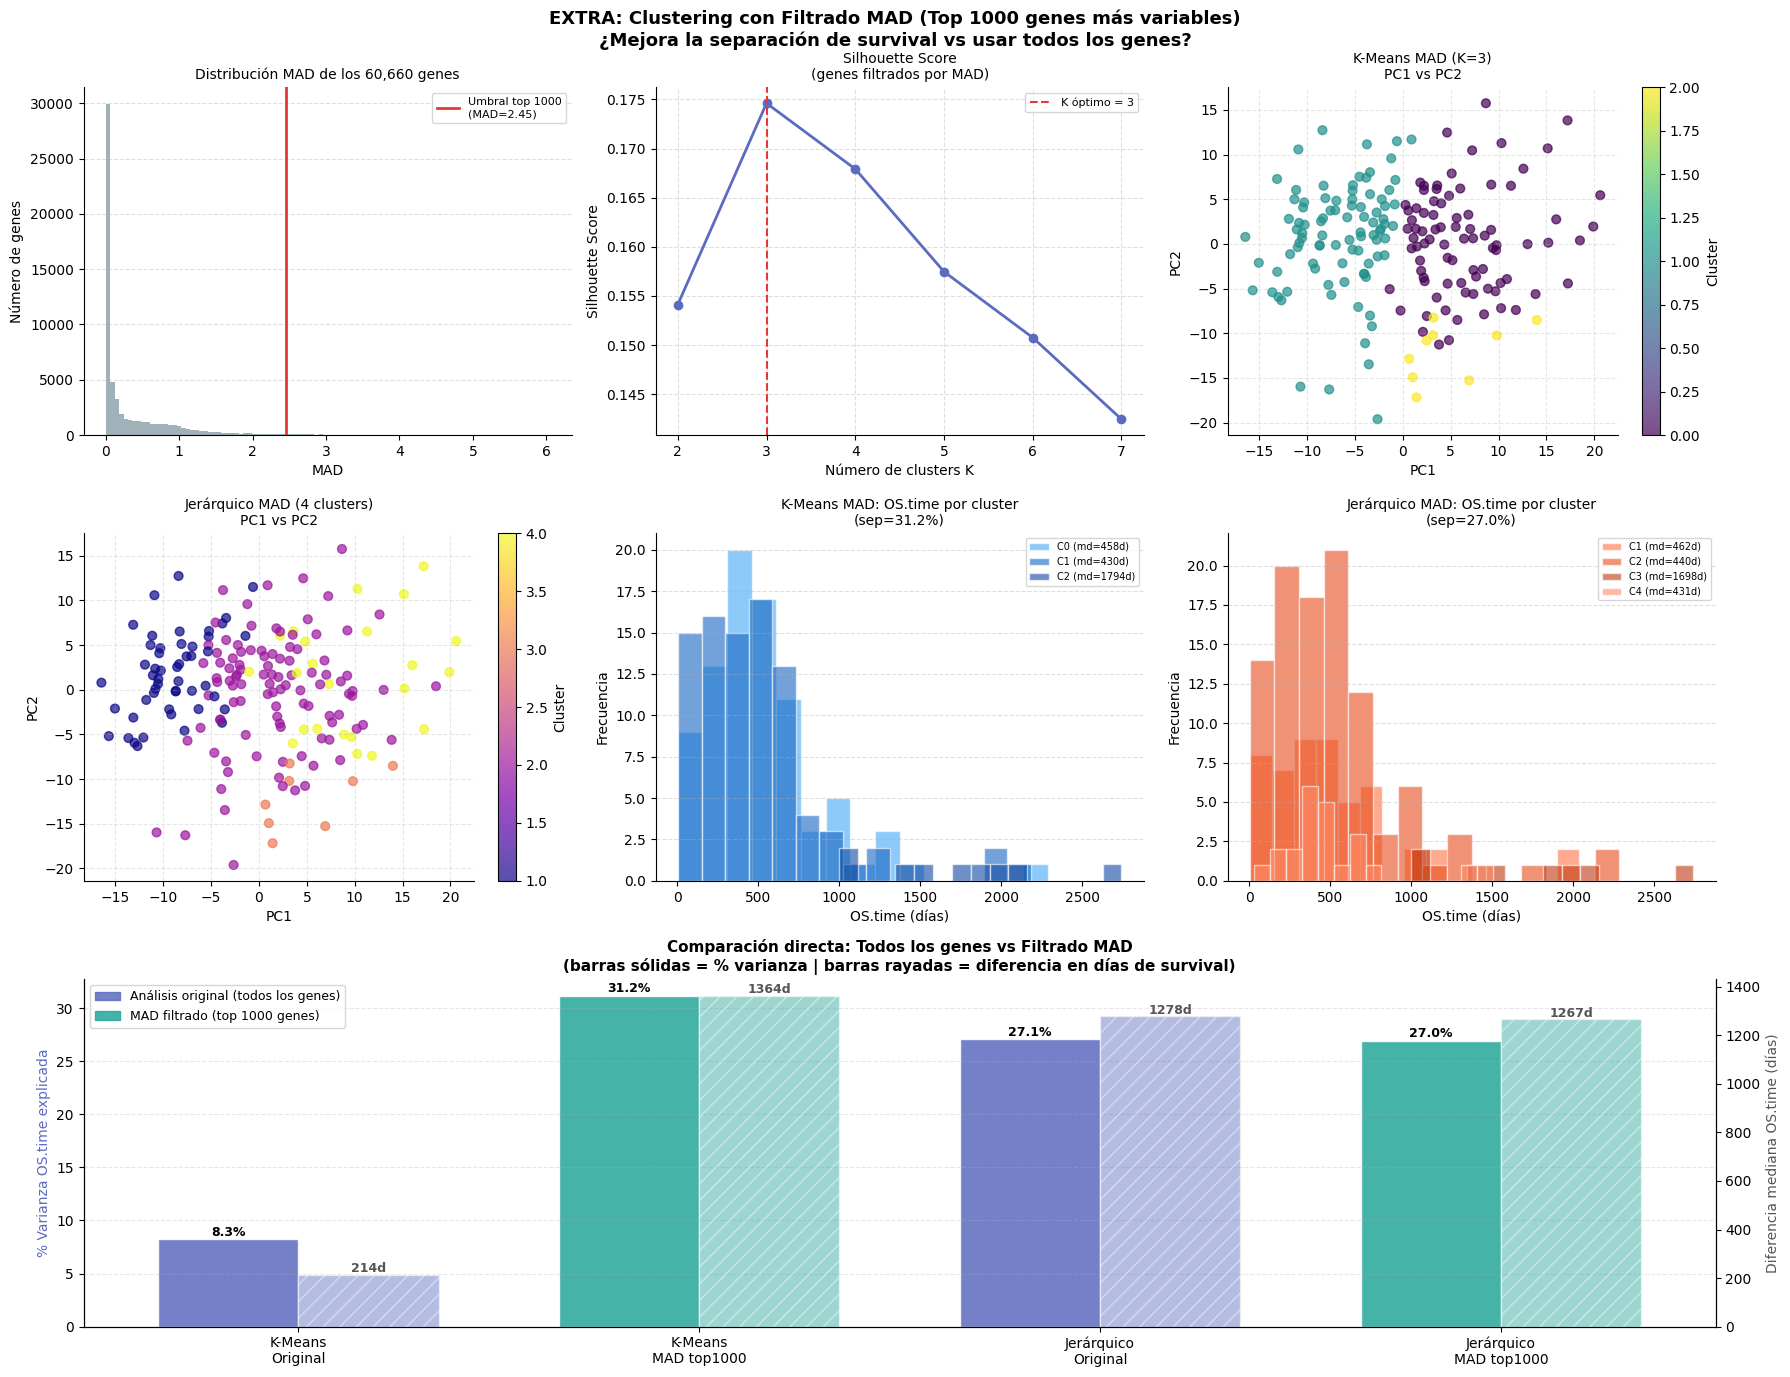


════════════════════════════════════════════════════════════
  RESUMEN: ¿Valió la pena filtrar por MAD?
════════════════════════════════════════════════════════════
Método                           % Var OS    Diff días
-------------------------------------------------------
K-Means original                    8.26%         214d
K-Means MAD top1000                31.19%        1364d
Jerárquico original                27.08%        1278d
Jerárquico MAD top1000             26.95%        1267d
════════════════════════════════════════════════════════════

  K-Means:    ↑ mejora en 22.93 puntos porcentuales
  Jerárquico: ↓ empeora en 0.13 puntos porcentuales


In [90]:
# ═══════════════════════════════════════════════════════════════════
# EXTRA: Clustering con filtrado previo por varianza (MAD)
# ¿Mejora la calidad si solo usamos los genes más variables?
# ═══════════════════════════════════════════════════════════════════

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

# ─── 1. Filtrar genes por MAD (Median Absolute Deviation) ─────────────────────
# MAD es más robusto que la varianza estándar para datos genómicos con outliers
mad_scores = tpm_processed.apply(lambda x: (x - x.median()).abs().median(), axis=0)
  # MAD por gen (columnas = genes)

# Probar con top 500, 1000 y 2000 genes más variables
n_top_genes_options = [500, 1000, 2000]

print(f"Total de genes disponibles: {tpm_processed.shape[1]}")
print(f"MAD promedio: {mad_scores.mean():.4f} | MAD mediana: {mad_scores.median():.4f}")
print(f"\nGenes seleccionados por umbral MAD:")
for n in n_top_genes_options:
    threshold = mad_scores.nlargest(n).min()
    print(f"  Top {n:,} genes → umbral MAD ≥ {threshold:.4f}")

# Usaremos top 1000 como balance entre señal y dimensionalidad
N_MAD_GENES = 1000
top_mad_genes = mad_scores.nlargest(N_MAD_GENES).index

# Filtrar el dataset de expresión
tpm_mad_filtered = tpm_processed[top_mad_genes]
print(f"\nShape del dataset filtrado por MAD (top {N_MAD_GENES}): {tpm_mad_filtered.shape}")

# ─── 2. Estandarizar y aplicar PCA al dataset filtrado ────────────────────────
scaler_mad = StandardScaler()
tpm_mad_scaled = scaler_mad.fit_transform(tpm_mad_filtered)

# PCA — ver cuánta varianza capturan los primeros componentes ahora
pca_mad_full = PCA()
pca_mad_full.fit(tpm_mad_scaled)
cumvar_mad = np.cumsum(pca_mad_full.explained_variance_ratio_)
n_components_95_mad = np.argmax(cumvar_mad >= 0.95) + 1

print(f"\nCon top {N_MAD_GENES} genes MAD:")
print(f"  PCs para explicar 95% varianza: {n_components_95_mad} (antes eran 163 con todos los genes)")

# Reducir a 10 PCs (mismo criterio que el análisis original para comparar fair)
pca_mad_10 = PCA(n_components=10)
tpm_mad_pca = pca_mad_10.fit_transform(tpm_mad_scaled)
pca_mad_df = pd.DataFrame(tpm_mad_pca, index=tpm_mad_filtered.index,
                           columns=[f'PC{i+1}' for i in range(10)])

var_original = sum(pca_10_components.explained_variance_ratio_) * 100
var_mad      = sum(pca_mad_10.explained_variance_ratio_) * 100
print(f"  Varianza explicada en 10 PCs (todos los genes): {var_original:.1f}%")
print(f"  Varianza explicada en 10 PCs (MAD filtrado):    {var_mad:.1f}%")

# ─── 3. Silhouette para elegir K óptimo en el dataset MAD ─────────────────────
k_range = range(2, 8)
sil_scores_mad = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_mad_df)
    sil_scores_mad.append(silhouette_score(pca_mad_df, km.labels_))

k_optimal_mad = list(k_range)[np.argmax(sil_scores_mad)]
print(f"\nK óptimo por Silhouette (MAD): {k_optimal_mad}")
print(f"Silhouette original (K=2, todos genes): 0.xxxx → ver celda anterior")
print(f"Silhouette MAD filtrado (K={k_optimal_mad}): {max(sil_scores_mad):.4f}")

# ─── 4. Aplicar K-Means y Jerárquico con genes MAD ───────────────────────────
# K-Means
kmeans_mad = KMeans(n_clusters=k_optimal_mad, random_state=42, n_init=10)
kmeans_mad.fit(pca_mad_df)
kmeans_mad_labels = kmeans_mad.labels_

# Jerárquico (mismo criterio ward que antes)
Z_mad = linkage(pca_mad_df, method='ward')
# Usar mismo número de clusters que el jerárquico original (4) para comparar
hier_mad_labels = fcluster(Z_mad, t=4, criterion='maxclust')

sil_kmeans_mad = silhouette_score(pca_mad_df, kmeans_mad_labels)
sil_hier_mad   = silhouette_score(pca_mad_df, hier_mad_labels)

print(f"\nSilhouette K-Means MAD (K={k_optimal_mad}): {sil_kmeans_mad:.4f}")
print(f"Silhouette Jerárquico MAD (4 clusters):     {sil_hier_mad:.4f}")

# ─── 5. Métricas de survival para los nuevos clusters ─────────────────────────
# Reutilizamos la función del análisis anterior
def cluster_separation_score(df, cluster_col, target_col):
    overall_mean = df[target_col].mean()
    total_var = ((df[target_col] - overall_mean) ** 2).sum()
    between_var = sum(
        len(g) * (g[target_col].mean() - overall_mean) ** 2
        for _, g in df.groupby(cluster_col)
    )
    return between_var / total_var if total_var > 0 else 0

# Preparar dataframe con clusters MAD + survival
mad_cluster_df = pca_mad_df.copy().reset_index().rename(columns={'index': 'sample'})
mad_cluster_df['sample'] = mad_cluster_df['sample'].apply(
    lambda x: x[:-4] if x.endswith('-01A') else x
)
mad_cluster_df['kmeans_mad'] = kmeans_mad_labels
mad_cluster_df['hier_mad']   = hier_mad_labels

survival_clean = survival.copy()
survival_clean['sample'] = survival_clean['sample'].apply(
    lambda x: x[:-4] if x.endswith('-01A') else x
)

mad_analysis_df = mad_cluster_df.merge(survival_clean[['sample', 'OS.time', 'OS']], on='sample', how='inner')

sep_kmeans_mad = cluster_separation_score(mad_analysis_df, 'kmeans_mad', 'OS.time')
sep_hier_mad   = cluster_separation_score(mad_analysis_df, 'hier_mad',   'OS.time')

diff_km_mad   = (mad_analysis_df.groupby('kmeans_mad')['OS.time'].median().max() -
                 mad_analysis_df.groupby('kmeans_mad')['OS.time'].median().min())
diff_hier_mad = (mad_analysis_df.groupby('hier_mad')['OS.time'].median().max() -
                 mad_analysis_df.groupby('hier_mad')['OS.time'].median().min())

print(f"\n── Separación de survival (MAD filtrado) ──────────────────────")
print(f"K-Means MAD:    {sep_kmeans_mad*100:.2f}% varianza OS | diff mediana: {diff_km_mad:.0f} días")
print(f"Jerárquico MAD: {sep_hier_mad*100:.2f}% varianza OS | diff mediana: {diff_hier_mad:.0f} días")
print(f"\n── Comparación con análisis original ──────────────────────────")
print(f"K-Means original:    8.26% varianza OS | diff mediana: 214 días")
print(f"Jerárquico original: 27.08% varianza OS | diff mediana: 1278 días")

# ─── 6. VISUALIZACIÓN COMPLETA ────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(f'EXTRA: Clustering con Filtrado MAD (Top {N_MAD_GENES} genes más variables)\n'
             f'¿Mejora la separación de survival vs usar todos los genes?',
             fontsize=13, fontweight='bold')

# ── Panel 1: MAD distribution + umbral ──
ax1 = fig.add_subplot(3, 3, 1)
ax1.hist(mad_scores, bins=100, color='#78909C', alpha=0.7, edgecolor='none')
threshold_line = mad_scores.nlargest(N_MAD_GENES).min()
ax1.axvline(threshold_line, color='#E53935', linewidth=2,
            label=f'Umbral top {N_MAD_GENES}\n(MAD={threshold_line:.2f})')
ax1.set_title(f'Distribución MAD de los {tpm_processed.shape[1]:,} genes', fontsize=10)
ax1.set_xlabel('MAD')
ax1.set_ylabel('Número de genes')
ax1.legend(fontsize=8)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel 2: Silhouette scores MAD ──
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(list(k_range), sil_scores_mad, marker='o', color='#5C6BC0', linewidth=2)
ax2.axvline(k_optimal_mad, color='#E53935', linestyle='--',
            label=f'K óptimo = {k_optimal_mad}')
ax2.set_title('Silhouette Score\n(genes filtrados por MAD)', fontsize=10)
ax2.set_xlabel('Número de clusters K')
ax2.set_ylabel('Silhouette Score')
ax2.legend(fontsize=8)
ax2.grid(linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

# ── Panel 3: Scatter PCA — K-Means MAD ──
ax3 = fig.add_subplot(3, 3, 3)
scatter = ax3.scatter(pca_mad_df['PC1'], pca_mad_df['PC2'],
                      c=kmeans_mad_labels, cmap='viridis', alpha=0.7, s=40)
plt.colorbar(scatter, ax=ax3, label='Cluster')
ax3.set_title(f'K-Means MAD (K={k_optimal_mad})\nPC1 vs PC2', fontsize=10)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.grid(linestyle='--', alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)

# ── Panel 4: Scatter PCA — Jerárquico MAD ──
ax4 = fig.add_subplot(3, 3, 4)
scatter2 = ax4.scatter(pca_mad_df['PC1'], pca_mad_df['PC2'],
                       c=hier_mad_labels, cmap='plasma', alpha=0.7, s=40)
plt.colorbar(scatter2, ax=ax4, label='Cluster')
ax4.set_title('Jerárquico MAD (4 clusters)\nPC1 vs PC2', fontsize=10)
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.grid(linestyle='--', alpha=0.3)
ax4.spines[['top', 'right']].set_visible(False)

# ── Panel 5: OS.time por cluster K-Means MAD ──
ax5 = fig.add_subplot(3, 3, 5)
palette_km = ['#42A5F5', '#1565C0', '#0D47A1', '#82B1FF']
for i, cid in enumerate(sorted(mad_analysis_df['kmeans_mad'].unique())):
    data = mad_analysis_df[mad_analysis_df['kmeans_mad'] == cid]['OS.time'].dropna()
    ax5.hist(data, bins=15, alpha=0.6, color=palette_km[i % len(palette_km)],
             label=f'C{cid} (md={data.median():.0f}d)', edgecolor='white')
ax5.set_title(f'K-Means MAD: OS.time por cluster\n(sep={sep_kmeans_mad*100:.1f}%)', fontsize=10)
ax5.set_xlabel('OS.time (días)')
ax5.set_ylabel('Frecuencia')
ax5.legend(fontsize=7)
ax5.grid(axis='y', linestyle='--', alpha=0.4)
ax5.spines[['top', 'right']].set_visible(False)

# ── Panel 6: OS.time por cluster Jerárquico MAD ──
ax6 = fig.add_subplot(3, 3, 6)
palette_hier = ['#FF7043', '#E64A19', '#BF360C', '#FF8A65']
for i, cid in enumerate(sorted(mad_analysis_df['hier_mad'].unique())):
    data = mad_analysis_df[mad_analysis_df['hier_mad'] == cid]['OS.time'].dropna()
    ax6.hist(data, bins=15, alpha=0.6, color=palette_hier[i % len(palette_hier)],
             label=f'C{cid} (md={data.median():.0f}d)', edgecolor='white')
ax6.set_title(f'Jerárquico MAD: OS.time por cluster\n(sep={sep_hier_mad*100:.1f}%)', fontsize=10)
ax6.set_xlabel('OS.time (días)')
ax6.set_ylabel('Frecuencia')
ax6.legend(fontsize=7)
ax6.grid(axis='y', linestyle='--', alpha=0.4)
ax6.spines[['top', 'right']].set_visible(False)

# ── Panel 7-9: Comparación directa original vs MAD ──
ax7 = fig.add_subplot(3, 3, (7, 9))

metodos   = ['K-Means\nOriginal', f'K-Means\nMAD top{N_MAD_GENES}',
             'Jerárquico\nOriginal', f'Jerárquico\nMAD top{N_MAD_GENES}']
sep_vals  = [8.26, sep_kmeans_mad * 100, 27.08, sep_hier_mad * 100]
diff_vals = [214,  diff_km_mad,           1278,  diff_hier_mad]

x     = np.arange(len(metodos))
width = 0.35
c1, c2 = '#5C6BC0', '#26A69A'

bars1 = ax7.bar(x - width/2, sep_vals,  width, label='% Varianza OS explicada',
                color=[c1 if 'Original' in m else c2 for m in metodos], alpha=0.85, edgecolor='white')

ax7b = ax7.twinx()
bars2 = ax7b.bar(x + width/2, diff_vals, width, label='Diff. mediana OS.time (días)',
                 color=[c1 if 'Original' in m else c2 for m in metodos], alpha=0.45,
                 edgecolor='white', hatch='//')

for bar, val in zip(bars1, sep_vals):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

for bar, val in zip(bars2, diff_vals):
    ax7b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
              f'{val:.0f}d', ha='center', fontsize=9, fontweight='bold', color='#555')

ax7.set_xticks(x)
ax7.set_xticklabels(metodos, fontsize=10)
ax7.set_ylabel('% Varianza OS.time explicada', fontsize=10, color=c1)
ax7b.set_ylabel('Diferencia mediana OS.time (días)', fontsize=10, color='#555')
ax7.set_title('Comparación directa: Todos los genes vs Filtrado MAD\n'
              '(barras sólidas = % varianza | barras rayadas = diferencia en días de survival)',
              fontsize=11, fontweight='bold')

original_patch = mpatches.Patch(color=c1, alpha=0.85, label='Análisis original (todos los genes)')
mad_patch      = mpatches.Patch(color=c2, alpha=0.85, label=f'MAD filtrado (top {N_MAD_GENES} genes)')
ax7.legend(handles=[original_patch, mad_patch], fontsize=9, loc='upper left')
ax7.grid(axis='y', linestyle='--', alpha=0.3)
ax7.spines[['top']].set_visible(False)
ax7b.spines[['top']].set_visible(False)

plt.tight_layout()
plt.savefig('extra_mad_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 7. Resumen final ─────────────────────────────────────────────────────────
print(f"\n{'═'*60}")
print(f"  RESUMEN: ¿Valió la pena filtrar por MAD?")
print(f"{'═'*60}")
print(f"{'Método':<30} {'% Var OS':>10} {'Diff días':>12}")
print(f"{'-'*55}")
print(f"{'K-Means original':<30} {'8.26%':>10} {'214d':>12}")
print(f"{f'K-Means MAD top{N_MAD_GENES}':<30} {sep_kmeans_mad*100:>9.2f}% {diff_km_mad:>11.0f}d")
print(f"{'Jerárquico original':<30} {'27.08%':>10} {'1278d':>12}")
print(f"{f'Jerárquico MAD top{N_MAD_GENES}':<30} {sep_hier_mad*100:>9.2f}% {diff_hier_mad:>11.0f}d")
print(f"{'═'*60}")
mejora_km   = sep_kmeans_mad*100 - 8.26
mejora_hier = sep_hier_mad*100 - 27.08
print(f"\n  K-Means:    {'↑ mejora' if mejora_km > 0 else '↓ empeora'} en {abs(mejora_km):.2f} puntos porcentuales")
print(f"  Jerárquico: {'↑ mejora' if mejora_hier > 0 else '↓ empeora'} en {abs(mejora_hier):.2f} puntos porcentuales")

Con esto vimos que podemos mejorar la clasificación de nuestro algoritmo filtrando genes por varianza, reduciendo el ruido de los datos y permitiendo una mejora al modelo de k-means, el cual mejoro en casi 23 puntos porcentuales, lo cual es una mejora bastante buena.